In [3]:
%pip install pandas
%pip install numpy
%pip install scikit-learn
%pip install matplotlib
%pip install seaborn
import pandas as pd
import numpy as np
df = pd.read_csv(r'C:\Users\EL095\Microsoft\20260515\bmw_feature_engineering.csv')  

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 데이터 컬럼명 정리


In [4]:
import pandas as pd

# 1. 필요한 컬럼 선택
selected_cols = [
    "Time [s]",
    "source_file",

    "Battery Voltage [V]",
    "Battery Current [A]",
    "Battery Temperature [°C]",
    "Ambient Temperature [°C]",

    "Delta_t",
    "Delta_V",
    "Delta_I",
    "Delta_T",
    "Delta_P",

    "Battery_Power",

    "dV_dt",
    "dI_dt",
    "dT_dt",
    "dP_dt",

    "Battery_Mode",
    "Temp_Diff"
]

# 2. TripB 데이터만 필터링
tripb_df = df[
    df["source_file"].str.contains(
        "TripB",
        case=False,
        na=False
    )
][selected_cols].copy()

# 3. 컬럼명 간단하게 변경
rename_cols = {
    "Time [s]": "time",
    "source_file": "source",

    "Battery Voltage [V]": "voltage",
    "Battery Current [A]": "current",
    "Battery Temperature [°C]": "battery_temp",
    "Ambient Temperature [°C]": "ambient_temp",

    "Delta_t": "delta_t",
    "Delta_V": "delta_v",
    "Delta_I": "delta_i",
    "Delta_T": "delta_t_temp",
    "Delta_P": "delta_p",

    "Battery_Power": "power",

    "dV_dt": "dv_dt",
    "dI_dt": "di_dt",
    "dT_dt": "dt_dt",
    "dP_dt": "dp_dt",

    "Battery_Mode": "mode",
    "Temp_Diff": "temp_diff"
}

tripb_df = tripb_df.rename(columns=rename_cols)

# 4. 상위 10개 확인
print(tripb_df.head(10))

        time       source  voltage   current  battery_temp  ambient_temp  \
467701   0.0  TripB01.csv    388.8 -19.06128           7.0           8.5   
467702   0.1  TripB01.csv    388.8 -19.06128           7.0           8.5   
467703   0.2  TripB01.csv    388.8 -18.86127           7.0           8.5   
467704   0.3  TripB01.csv    388.8 -18.69031           7.0           8.5   
467705   0.4  TripB01.csv    388.8 -18.64031           7.0           8.5   
467706   0.5  TripB01.csv    388.8 -18.58062           7.0           8.5   
467707   0.6  TripB01.csv    388.8 -18.48061           7.0           8.5   
467708   0.7  TripB01.csv    388.8 -18.37091           7.0           8.5   
467709   0.8  TripB01.csv    388.8 -18.22091           7.0           8.5   
467710   0.9  TripB01.csv    388.8 -18.11940           7.0           8.5   

        delta_t  delta_v   delta_i  delta_t_temp      delta_p        power  \
467701  -1672.1     12.4 -16.62128         -19.0 -6492.609664 -7411.025664   
467702 

# 데이터 전처리

In [5]:
tripb_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 491184 entries, 467701 to 958884
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   time          491184 non-null  float64
 1   source        491184 non-null  str    
 2   voltage       491184 non-null  float64
 3   current       491184 non-null  float64
 4   battery_temp  491184 non-null  float64
 5   ambient_temp  491184 non-null  float64
 6   delta_t       491184 non-null  float64
 7   delta_v       491184 non-null  float64
 8   delta_i       491184 non-null  float64
 9   delta_t_temp  491184 non-null  float64
 10  delta_p       491184 non-null  float64
 11  power         491184 non-null  float64
 12  dv_dt         491184 non-null  float64
 13  di_dt         491184 non-null  float64
 14  dt_dt         491184 non-null  float64
 15  dp_dt         491184 non-null  float64
 16  mode          491184 non-null  str    
 17  temp_diff     491184 non-null  float64
dtypes: float64

In [6]:
tripb_df.isnull().sum()

time            0
source          0
voltage         0
current         0
battery_temp    0
ambient_temp    0
delta_t         0
delta_v         0
delta_i         0
delta_t_temp    0
delta_p         0
power           0
dv_dt           0
di_dt           0
dt_dt           0
dp_dt           0
mode            0
temp_diff       0
dtype: int64

In [7]:
tripb_df.duplicated().sum()

np.int64(0)

In [8]:
tripb_df = tripb_df.sort_values(
    by="time"
)

### 물리적으로 불가능한 값 삭제

In [9]:
tripb_df = tripb_df[
    (tripb_df["voltage"] > 0)
    &
    (tripb_df["battery_temp"] > -50)
    &
    (tripb_df["battery_temp"] < 100)
]

In [10]:
tripb_df.describe()

,time,voltage,current,battery_temp,ambient_temp,delta_t,delta_v,delta_i,delta_t_temp,delta_p,power,dv_dt,di_dt,dt_dt,dp_dt,temp_diff
count,491184.000000,491184.000000,491184.000000,491184.000000,491184.000000,491184.000000,491184.000000,491184.000000,491184.000000,491184.000000,491184.000000,491184.000000,491184.000000,491184.000000,491184.000000,491184.000000
mean,1257.765577,372.238329,-16.742003,10.857220,6.080940,-0.003171,-0.000031,-0.000005,-0.000041,-0.001755,-5825.152068,-0.005650,0.002914,0.001975,1.173958,4.776279
std,1103.253334,12.185465,51.055398,4.866685,2.801918,16.038050,0.334869,2.575724,0.057752,916.357840,18497.934275,3.180087,25.688920,0.102097,9135.820755,4.638009
min,0.000000,308.600000,-404.380000,0.000000,1.000000,-5610.100000,-10.800000,-103.940000,-19.000000,-36704.780000,-138682.121000,-108.000000,-1039.400000,-8.300000,-335817.879999,-6.000000
25%,454.200000,364.450000,-35.300000,8.000000,3.500000,0.100000,-0.070000,-0.650000,0.000000,-235.943250,-13021.806250,-0.700000,-6.500000,0.000000,-2358.566250,2.000000
50%,938.800000,373.320000,-12.510000,11.000000,5.500000,0.100000,0.000000,-0.010000,0.000000,-4.654450,-4679.227200,0.000000,-0.100000,0.000000,-45.485697,4.500000
75%,1737.100000,381.700000,-1.710000,14.000000,9.000000,0.100000,0.050000,0.450000,0.000000,164.599500,-640.225325,0.500000,4.500000,0.000000,1645.650000,7.000000
max,5610.100000,394.080000,144.490000,22.000000,14.000000,0.100000,28.500000,132.990000,7.000000,49076.999400,53024.355000,171.600000,1329.900000,10.000000,490769.994000,17.500000


# EDA

## 분포 확인

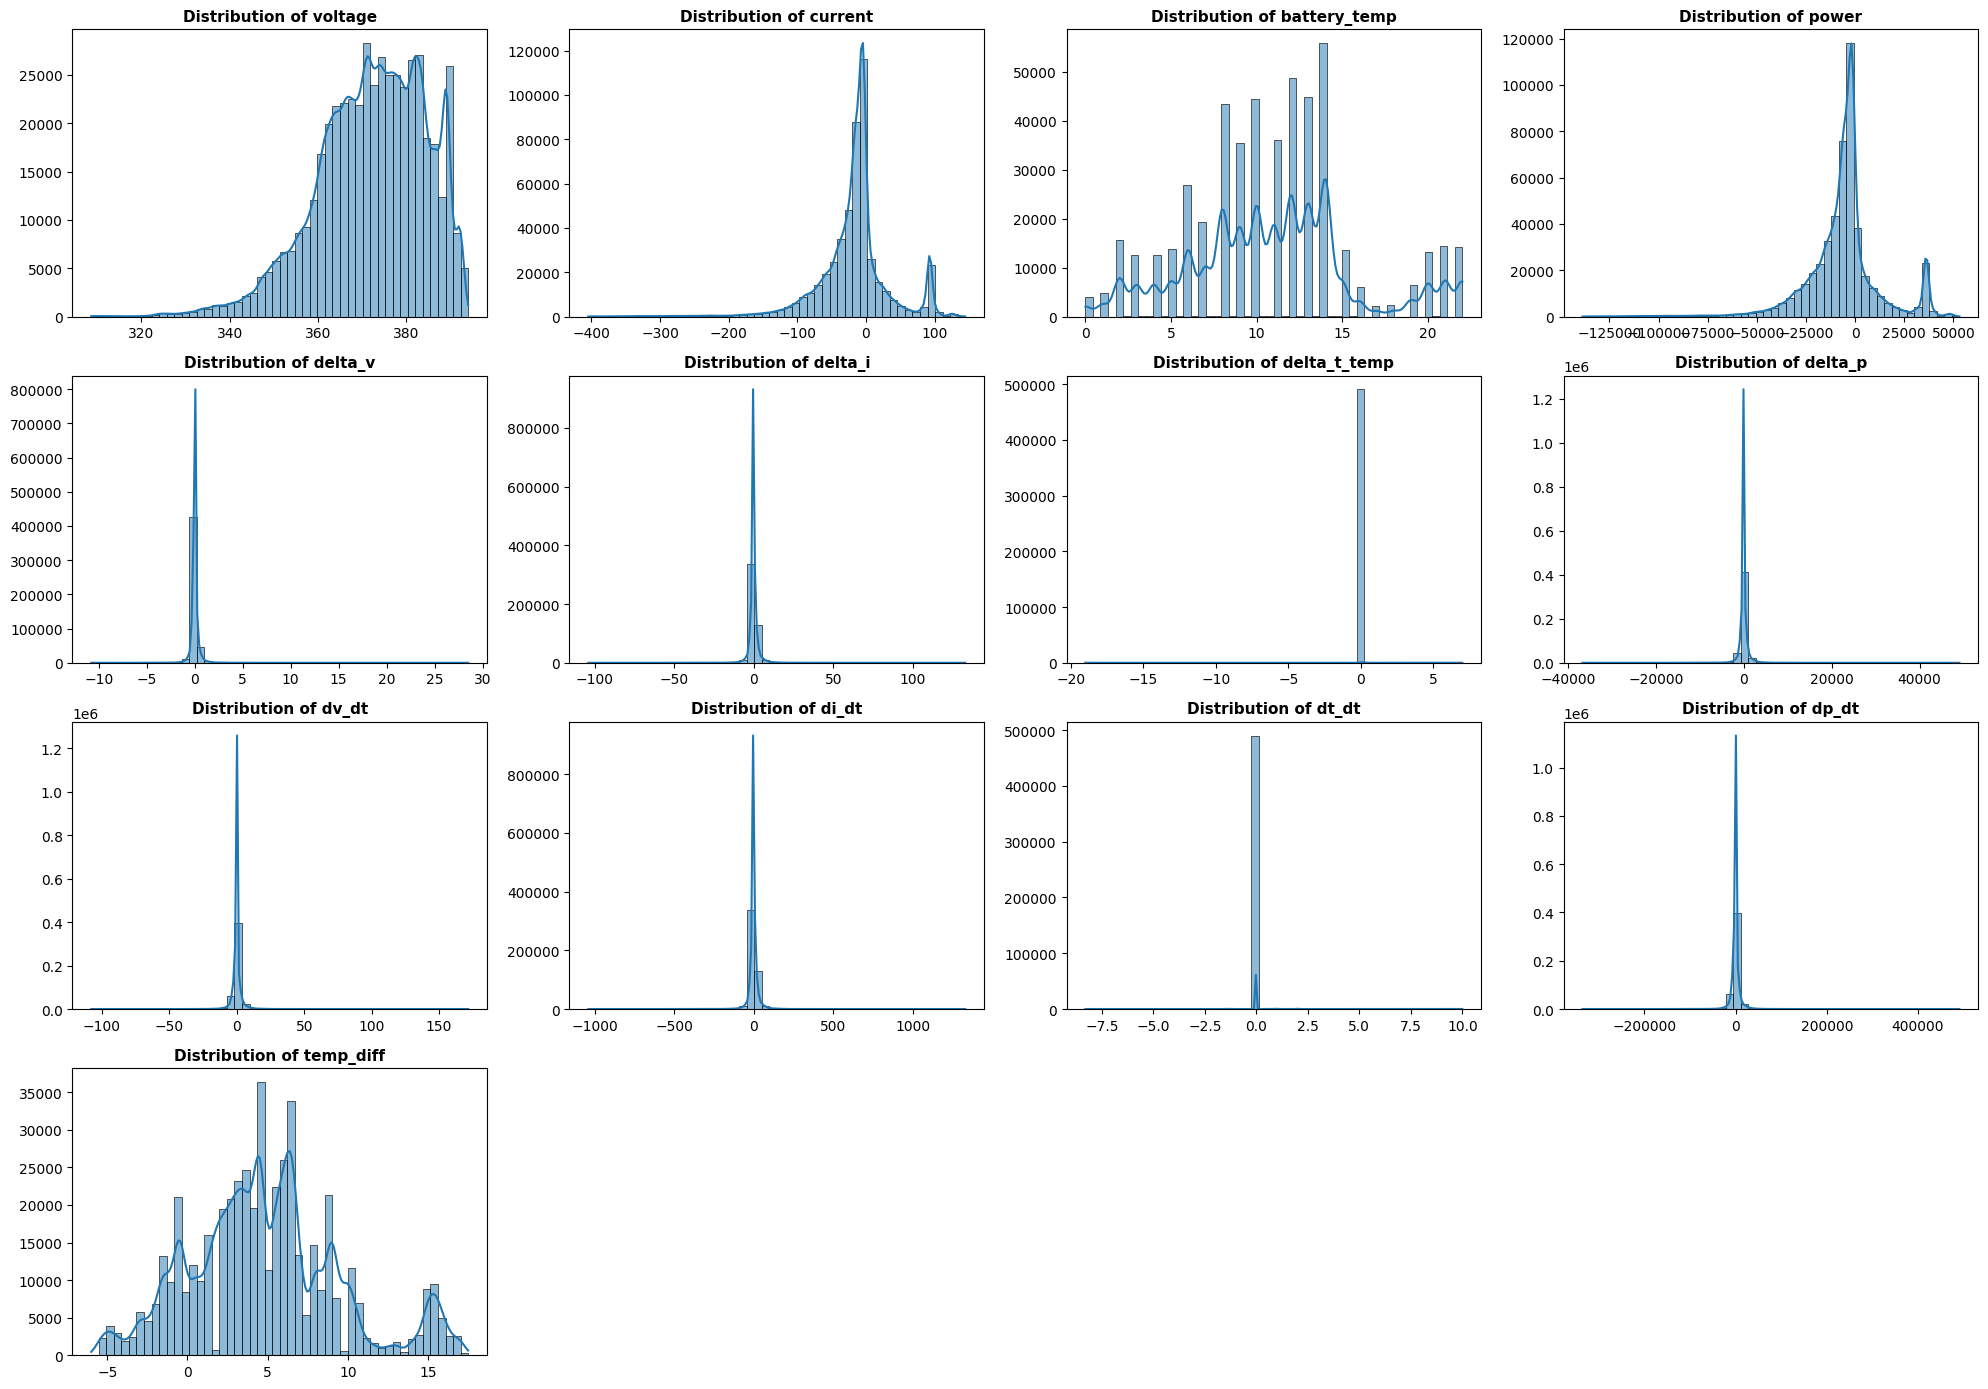

In [11]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    "voltage",
    "current",
    "battery_temp",
    "power",
    "delta_v",
    "delta_i",
    "delta_t_temp",
    "delta_p",
    "dv_dt",
    "di_dt",
    "dt_dt",
    "dp_dt",
    "temp_diff",
]

# 1. 설정: 4열로 배치하고, 필요한 행(row)의 수를 동적으로 계산 (13개 피처 -> 4행 필요)
n_cols = 4
n_rows = math.ceil(len(features) / n_cols)

# 2. 전체 도화지(Figure) 생성 (가로 20, 세로는 행 개수에 맞춰 적절히 배분)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))

# 3. 2차원 배열 형태인 axes를 1차원 리스트로 평탄화 (for문 돌리기 편하게 만들기)
axes = axes.flatten()

# 4. 반복문을 돌며 각 서브플롯(ax)에 그래프 그리기
for i, col in enumerate(features):
    sns.histplot(
        data=tripb_df, x=col, kde=True, bins=50, ax=axes[i]  # 어떤 칸에 그릴지 지정
    )
    axes[i].set_title(f"Distribution of {col}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")  # x축 컬럼명이 타이틀과 중복되므로 깔끔하게 제거
    axes[i].set_ylabel("")  # y축 Count 라벨도 생략해서 가독성 높이기

# 5. 빈 칸 숨기기: 피처는 13개인데 총 칸수는 16개(4x4)이므로 남는 3개의 빈 그래프 레이아웃 제거
for j in range(len(features), len(axes)):
    axes[j].axis("off")

# 6. 그래프 간격 조절 및 출력
plt.tight_layout()
plt.show()

1. Voltage 분포 분석

전압(voltage)은 전체적으로 왼쪽 꼬리가 긴(left-skewed) 형태를 보였다. 대부분의 데이터는 약 360~385V 구간에 밀집되어 있었지만, 일부 구간에서 310~340V 수준의 낮은 전압 데이터가 존재하였다.

이는 특정 주행 상황에서 순간적인 전압 강하(voltage sag)가 발생했을 가능성을 의미한다. 전압 강하는 급격한 부하 증가, 급가속, 배터리 셀 불균형, 또는 방전 스트레스 상황과 관련될 수 있다.

따라서 전압 관련 feature는 배터리 안정성 및 이상 탐지에서 중요한 변수로 활용 가능하다.

2. Current 분포 분석

전류(current)는 음수 방향으로 긴 꼬리를 가지는 비대칭 분포를 보였다.

전기차에서 음수 전류는 일반적으로 방전(discharge)을 의미하며, 큰 음수 전류 값은 고출력 사용 상황 또는 급가속 상황과 연관될 수 있다.

특히 -400A 수준의 극단적인 전류 값이 존재하였으며, 이는 배터리에 높은 부하(stress)를 유발할 가능성이 있다.

따라서 전류 데이터는 배터리 스트레스 및 과부하 탐지에 핵심적인 feature로 판단된다.

3. Battery Temperature 분포 분석

배터리 온도(battery_temp)는 비교적 안정적인 분포를 보였으며, 극단적인 이상치는 많지 않았다.

이는 실제 차량의 BMS(Battery Management System) 및 냉각 시스템이 정상적으로 작동하며 배터리 온도를 일정 수준 내에서 제어하고 있음을 의미할 수 있다.

그러나 일부 고온 구간은 장시간 고부하 주행 또는 외부 환경 영향 가능성을 시사한다.

따라서 배터리 온도 자체보다는 온도 변화율(dT/dt)과 함께 분석하는 것이 중요하다.

4. Power 분포 분석

전력(power)은 음수 방향으로 긴 꼬리를 보였다.

전기차에서 음수 전력은 배터리 방전을 의미하며, 큰 절댓값의 전력 사용은 급가속 또는 고출력 상황을 의미한다.

특히 일부 구간에서는 매우 높은 전력 사용량이 나타났으며, 이는 배터리 열화 및 발열 증가와 연결될 가능성이 있다.

따라서 power feature는 배터리 부하(stress)를 대표하는 핵심 지표로 활용 가능하다.

5. Delta_V (전압 변화량) 분포 분석

전압 변화량(delta_v)은 대부분 0 근처에 집중되어 있었으나, 일부 구간에서 큰 양수 및 음수 방향 이상치가 존재하였다.

이는 특정 시점에서 전압이 급격하게 변동했음을 의미하며, 회생제동(regenerative braking), 급부하 변화, 또는 셀 상태 불균형 가능성을 시사한다.

전압 변화량은 단순 전압값보다 이상징후를 민감하게 탐지할 수 있는 feature로 판단된다.

6. Delta_I (전류 변화량) 분포 분석

전류 변화량(delta_i)은 대부분 안정적인 범위 내에 존재하였으나, 일부 구간에서 매우 큰 급변 패턴이 확인되었다.

이는 급가속, 급감속, 또는 회생제동 전환 시점과 관련될 가능성이 있다.

급격한 전류 변화는 배터리 내부 스트레스를 증가시킬 수 있으므로 이상징후 탐지에 중요한 feature로 판단된다.

7. Delta_T (온도 변화량) 분포 분석

온도 변화량(delta_t_temp)은 대부분 0 근처에 분포하였으나 일부 구간에서 급격한 온도 변화가 존재하였다.

특히 순간적인 온도 상승 또는 하강은 냉각 시스템 작동, 환경 변화, 또는 비정상 발열 가능성과 관련될 수 있다.

따라서 온도 변화량은 열관리 이상 탐지에 활용 가능한 feature로 판단된다.

8. Delta_P (전력 변화량) 분포 분석

전력 변화량(delta_p)은 대부분 0 근처에 집중되었으나 일부 극단값이 존재하였다.

이는 특정 순간에 전력 사용 패턴이 급격하게 변했음을 의미한다.

특히 급격한 전력 변화는 배터리 부하 변동성과 직접 관련될 가능성이 높으며, 이상 주행 패턴 탐지에 유용한 feature로 활용 가능하다.

9. dV/dt 분포 분석

전압 변화율(dv_dt)은 대부분 0 근처에 존재하였으나 일부 극단적인 변화율이 관측되었다.

이는 짧은 시간 내 전압이 급격하게 변한 상황을 의미하며, 배터리 상태 변화 또는 순간 부하 증가와 관련될 수 있다.

따라서 dV/dt는 배터리 안정성 평가에 중요한 feature로 판단된다.

10. dI/dt 분포 분석

전류 변화율(di_dt)은 극단적인 spike 패턴이 존재하였다.

이는 매우 짧은 시간 내 전류가 급격히 증가하거나 감소했음을 의미하며, 급가속 및 회생제동 상황 가능성을 시사한다.

전류 변화율은 배터리 스트레스와 직접적으로 연결될 가능성이 높은 feature이다.

11. dT/dt 분포 분석

온도 변화율(dt_dt)은 대부분 안정적인 범위 내에 존재하였으나 일부 급격한 온도 변화 패턴이 확인되었다.

이는 특정 순간 배터리 발열이 급증하거나 냉각 시스템이 급격히 작동했을 가능성을 의미한다.

온도 변화율은 열폭주(thermal runaway) 초기 탐지에 활용될 수 있는 feature로 판단된다.

12. dP/dt 분포 분석

전력 변화율(dp_dt)은 일부 극단적인 spike 패턴을 보였다.

이는 짧은 시간 내 배터리 부하가 급격하게 변한 상황을 의미한다.

특히 급격한 전력 변화는 배터리 열화 및 스트레스와 관련될 가능성이 높으므로 주요 이상 탐지 feature로 활용 가능하다.

13. Temp_Diff 분포 분석

외기온 보정 온도(temp_diff)는 대체로 정규분포 형태에 가까운 모습을 보였다.

그러나 일부 구간에서는 배터리 온도가 외기온보다 매우 높게 나타났으며, 이는 실제 배터리 내부 발열 가능성을 의미한다.

따라서 temp_diff는 외부 환경 영향을 제거한 실질적인 배터리 발열 지표로 활용 가능하다.

# 이상치 탐색

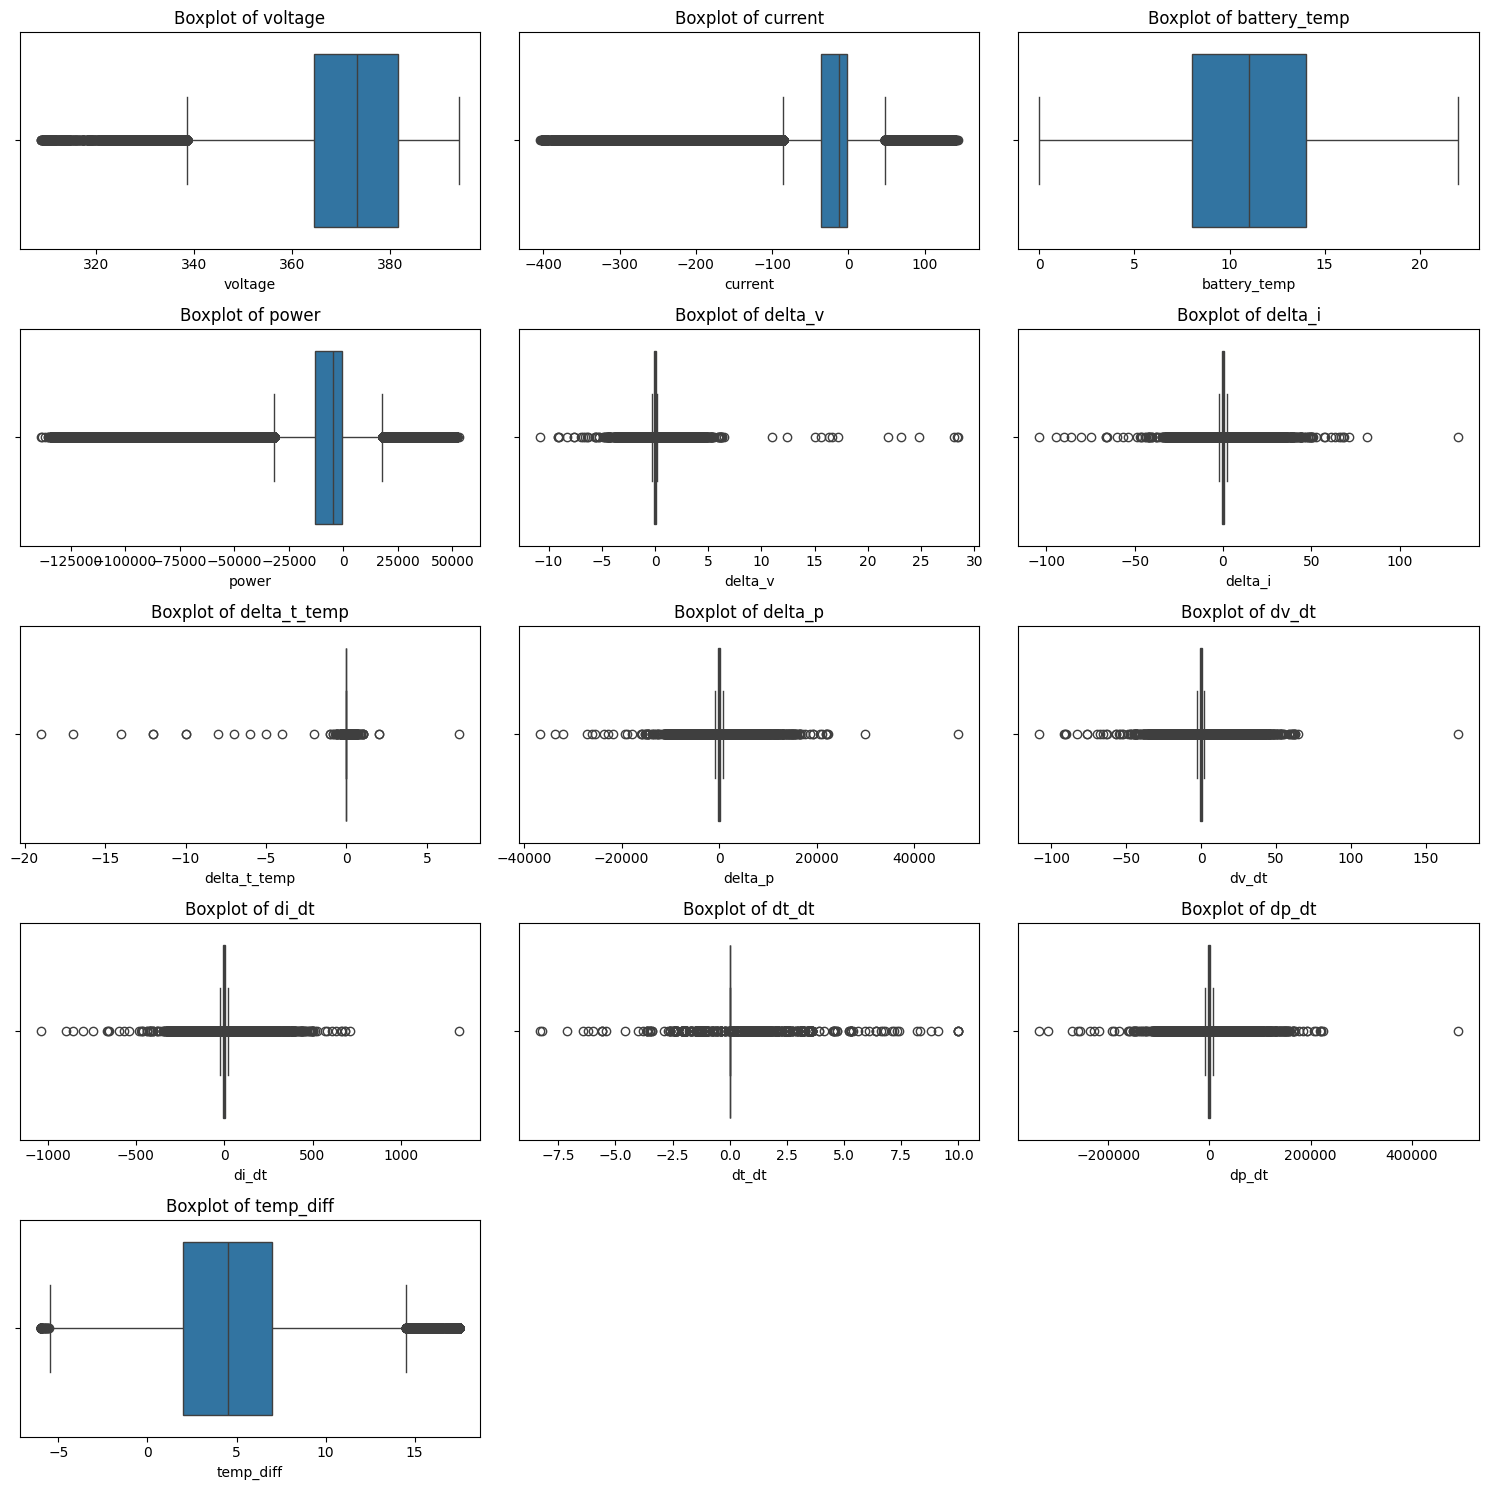

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

features = [
    "voltage",
    "current",
    "battery_temp",
    "power",

    "delta_v",
    "delta_i",
    "delta_t_temp",
    "delta_p",

    "dv_dt",
    "di_dt",
    "dt_dt",
    "dp_dt",

    "temp_diff"
]

# subplot 개수 계산
n_cols = 3
n_rows = math.ceil(len(features) / n_cols)

# figure 생성
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, n_rows * 3)
)

# axes 평탄화
axes = axes.flatten()

# boxplot 생성
for i, col in enumerate(features):

    sns.boxplot(
        x=tripb_df[col],
        ax=axes[i]
    )

    axes[i].set_title(f"Boxplot of {col}")

# 남는 subplot 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.show()

1. voltage : 낮은 전압 방향으로 이상치 다수 존재 -> 대부분은 360~ 385v에 집중 ( 전압 급락 발생을 의미  - 발생원인으로 가능한 것은 : 급가속, 순간 부하 증가, 셀 불균형, 방전 스트레스 )

2. current(전류) : 음수 방향 이상치 매우 많음, 양수 방향 이상치도 존재 ( 전기차에서 음수 전류 -> 방전, 양수 전류 -> 충전/회생제동을 의미 해당 그래프는 강한 방전 상황이 자주 발생했단는 의미 )
" 전류 데이터는 음수 방향으로 긴 꼬리를 보였으며,
이는 고출력 방전 상황이 반복적으로 발생했음을 의미한다.

특히 극단적인 전류 사용은
배터리 열화 및 스트레스 증가와 연결될 가능성이 있다."

3. battery_temp(배터리 온도)
* 이상치 거의 없음
* 비교적 안정적
* BMS와 냉각 시스템의 정상 작동을 시사 

4. power(전력) (= 배터리 부하 stress)
* 음수 방향 이상치 매우 큼
* 일부 양수 방향 존재 
* 고출력 방전 상황 빈번 - 급가속 및 고출력 사용 상황과 관련 

5. delta_v (전압 변화량)
* 대부분 0 근처
* 일부 극단적인 양수/음수 변화 조내
* 짧은 시간 내에 전압 급변 발생 - 회생 제동, 부하 급변, 셀 불안정 

6. delta_i (전류 변화량)

* 대부분 0 근처에 분포
* 일부 구간에서 극단적인 양수/음수 변화 존재
* 짧은 시간 내 전류 급변 발생
* 급가속, 급감속, 회생제동 전환 과정에서 발생 가능
* 배터리 내부 스트레스 증가 가능성을 시사

7. delta_t_temp (온도 변화량)

* 대부분 작은 범위 내에서 안정적으로 분포
* 일부 구간에서 급격한 온도 변화 존재
* 순간 발열 또는 냉각 시스템의 빠른 반응 가능성 존재
* 특정 상황에서 열관리 시스템이 적극적으로 개입했을 가능성 시사

8. delta_p (전력 변화량)

* 대부분 0 근처에 밀집
* 일부 극단적인 변화 패턴 존재
* 짧은 시간 내 전력 부하 급변 발생
* 급가속, 회생제동, 주행 패턴 변화와 관련 가능
* 배터리 부하 변동성이 존재함을 의미

9. dv_dt (전압 변화율)

* 대부분 안정적인 범위에 존재
* 일부 극단적인 spike 패턴 존재
* 짧은 시간 동안 전압이 급격히 변한 상황 발생
* 순간적인 부하 증가 또는 배터리 상태 변화 가능성 존재
* 배터리 안정성 이상 탐지에 활용 가능

10. di_dt (전류 변화율)

* 극단적인 spike 패턴 다수 존재
* 매우 짧은 시간 내 전류가 급격하게 증가하거나 감소
* 급가속 및 회생제동 전환 상황 가능성 존재
* 배터리 내부 스트레스와 높은 관련 가능성 존재
* 이상징후 탐지에 중요한 핵심 feature로 판단 가능

 11. dt_dt (온도 변화율)

* 대부분 안정적이나 일부 구간에서 급격한 변화 존재
* 순간적인 발열 증가 또는 냉각 반응 가능성 존재
* 특정 시점에서 열 상태가 급변한 패턴 확인
* 열폭주(Thermal Runaway) 초기 탐지 feature로 활용 가능

12. dp_dt (전력 변화율)

* 극단적인 양수/음수 spike 존재
* 짧은 시간 내 전력 사용량 급변 발생
* 배터리 부하 변화가 매우 빠르게 일어난 상황 의미
* 급가속, 회생제동, 운전 패턴 변화와 높은 관련 가능성 존재
* 배터리 stress 분석에 중요한 변수로 활용 가능

13. temp_diff (외기온 보정 온도)

* 비교적 안정적인 분포 형태
* 일부 구간에서 높은 양수 방향 이상치 존재
* 배터리 온도가 외기온보다 크게 상승한 상황 존재
* 외부 환경 영향보다 실제 배터리 내부 발열 가능성 시사
* 실질적인 배터리 발열 상태를 나타내는 핵심 feature로 활용 가능

### 전체 통합적 관점에서의 Insight

전체적으로 배터리 원천 데이터(voltage, current, battery_temp) 자체는 비교적 안정적인 분포를 보였으나, 변화량(delta) 및 변화율(d/dt) 기반 feature에서 극단적인 spike와 이상 패턴이 다수 관찰되었다. 이는 단순 상태값 자체보다 “짧은 시간 동안 얼마나 급격하게 변화하는가”가 배터리 이상징후 탐지에 더 중요한 정보일 가능성을 시사한다.

특히 전류 변화율(di_dt), 전력 변화율(dp_dt), 전압 변화율(dv_dt)에서는 반복적인 극단값이 확인되었으며, 이는 급가속, 회생제동, 순간적인 부하 증가와 같은 실제 주행 상황에서 배터리 스트레스가 집중적으로 발생하고 있음을 의미할 수 있다.

반면 배터리 온도 자체는 비교적 안정적으로 유지되었는데, 이는 차량의 BMS(Battery Management System)와 냉각 시스템이 정상적으로 작동하고 있음을 시사한다. 그러나 온도 변화율(dt_dt)과 외기온 보정 온도(temp_diff)에서는 일부 급격한 변화가 관찰되어, 특정 구간에서는 순간적인 발열 스트레스가 존재할 가능성이 확인되었다.

따라서 본 데이터는 단순 평균 기반 상태 분석보다 변화량 및 변화율 기반 anomaly detection에 적합한 특성을 가지고 있으며, 특히 spike 패턴과 극단적인 부하 변화를 활용한 실시간 이상징후 탐지 시스템 구축 가능성이 높다고 판단된다.


# Correlation 분석

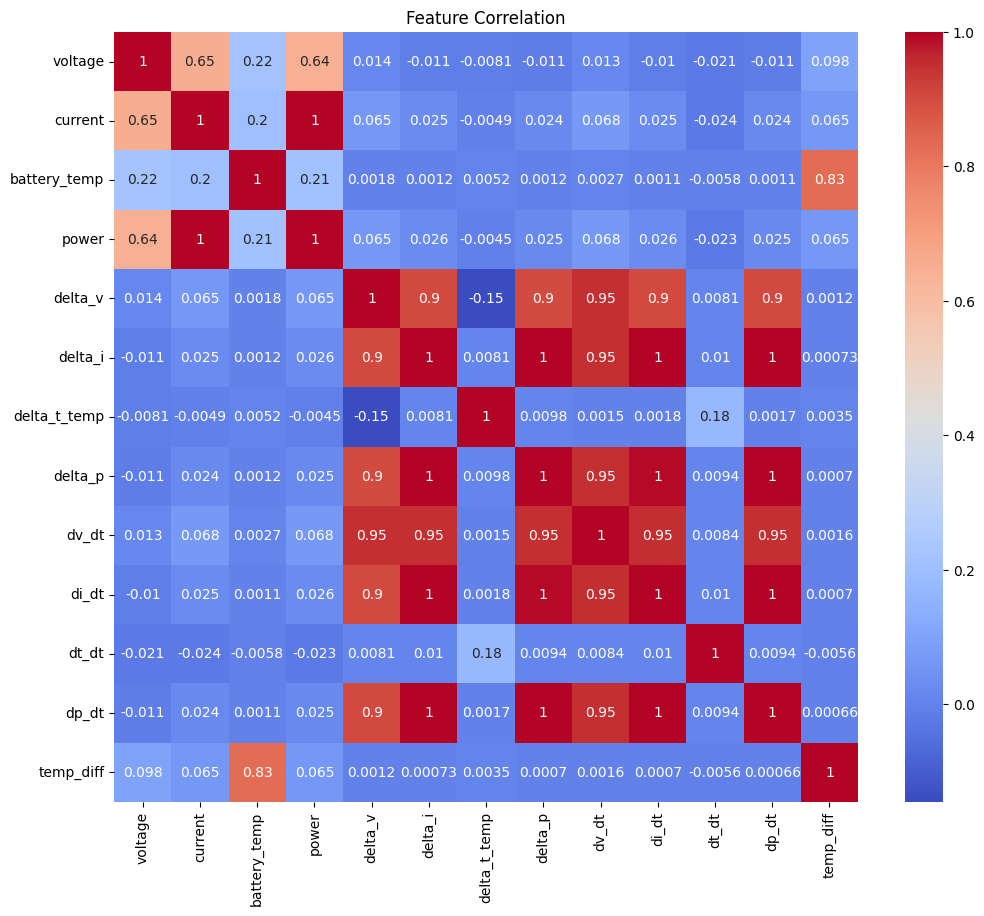

In [24]:
corr = tripb_df[features].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")

plt.show()

* current와 power의 상관계수가 거의 1에 가까움
→ 전력(power)이 전류(current)에 매우 크게 영향을 받고 있음을 의미
→ 실제로 전력은 Voltage × Current 기반으로 계산되기 때문에 물리적으로 자연스러운 결과

* delta_i, di_dt, delta_p, dp_dt 간 상관관계가 매우 높음
→ 전류 변화와 전력 변화가 동시에 발생하는 패턴 존재
→ 급가속·급감속·회생제동 시 순간 부하 변화가 강하게 발생하고 있음을 시사

* battery_temp와 temp_diff의 상관관계가 매우 높음 (0.83)
→ 외기온 보정 온도가 실제 배터리 온도에 크게 영향을 받고 있음을 의미
→ 배터리 발열 상태를 설명하는 주요 feature로 활용 가능

* delta_v, dv_dt, delta_p, dp_dt 간 강한 양의 상관관계 존재
→ 전압 급변이 전력 변화와 연결되는 패턴 존재
→ 부하 변화와 배터리 전기적 스트레스가 동시에 나타날 가능성 존재

* dt_dt는 대부분 변수와 상관관계가 낮음
→ 온도 변화율은 독립적인 이상징후 feature일 가능성 존재
→ 다른 전기적 변수와 별개로 thermal anomaly 탐지에 활용 가능

전체적으로 원본값(original feature)보다 변화량(delta) 및 변화율(d/dt) feature들 간의 상관성이 더 크게 나타남
→ 실제 이상징후는 절대값보다 “변화 패턴”에서 더 잘 나타날 가능성 시사

# 시계열 분석 

### (1) Voltage over time

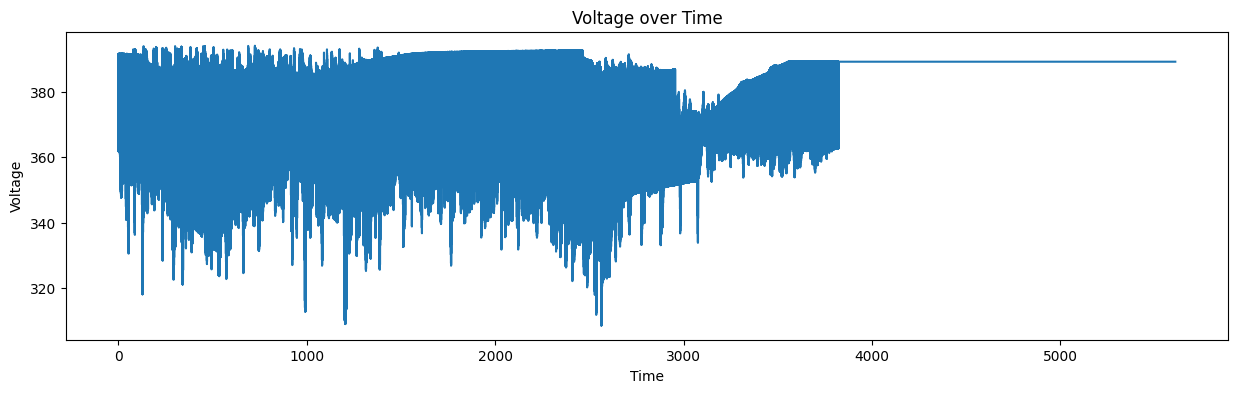

In [25]:
plt.figure(figsize=(15,4))

plt.plot(
    tripb_df["time"],
    tripb_df["voltage"]
)

plt.title("Voltage over Time")

plt.xlabel("Time")
plt.ylabel("Voltage")

plt.show()

전압은 전체적으로 360~390V 범위에서 안정적으로 유지됨
→ 배터리 시스템 전반은 정상 상태에 가까운 것으로 판단 가능
일부 구간에서 급격한 전압 하강(spike) 존재
→ 순간적인 고부하 상황 또는 급가속 가능성 존재
특정 시점에서 310V 수준까지 급락하는 패턴 관측
→ 순간적인 전압 불안정 또는 고전류 방전 가능성 존재
후반부로 갈수록 전압 변동폭 감소
→ 차량 주행 패턴 변화 또는 정속 주행 상태 진입 가능성 존재
장시간 평탄한 전압 유지 구간 존재
→ 배터리 안정화 또는 저부하 상태 가능성 존재

### (2) Temperature over time

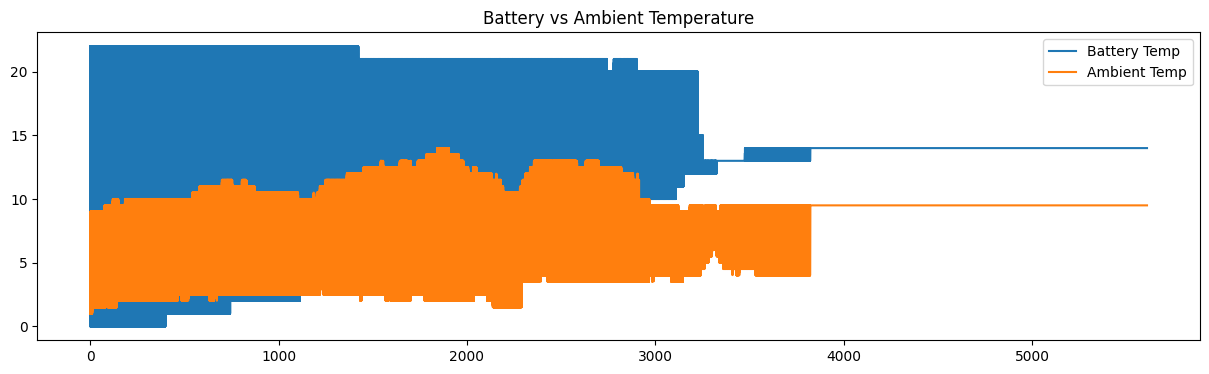

In [26]:
plt.figure(figsize=(15,4))

plt.plot(
    tripb_df["time"],
    tripb_df["battery_temp"],
    label="Battery Temp"
)

plt.plot(
    tripb_df["time"],
    tripb_df["ambient_temp"],
    label="Ambient Temp"
)

plt.legend()

plt.title("Battery vs Ambient Temperature")

plt.show()

배터리 온도가 외기온보다 지속적으로 높게 유지됨
→ 주행 중 배터리 내부 발열이 지속적으로 발생하고 있음을 의미
외기온 변화와 함께 배터리 온도도 일부 유사하게 변화
→ 외부 환경이 배터리 열 상태에 일정 부분 영향을 미치고 있음을 시사
배터리 온도가 외기온 대비 약 4~8°C 정도 높게 유지되는 구간 다수 존재
→ 정상적인 배터리 발열 범위 가능성 존재
특정 구간에서 온도 차이가 확대되는 패턴 존재
→ 순간적인 전력 사용 증가 또는 냉각 효율 저하 가능성 존재
극단적인 고온 현상은 크지 않음
→ 열관리 시스템(BMS 및 냉각 시스템)이 비교적 안정적으로 작동 중인 것으로 판단 가능

## Mode 별 분석

In [27]:
tripb_df.groupby("mode")[
    [
        "current",
        "power",
        "battery_temp",
        "temp_diff"
    ]
].mean()

,current,power,battery_temp,temp_diff
mode,,,,
Charging,42.796954,16472.670416,12.739169,5.416343
Discharging,-33.624564,-12147.765147,10.323459,4.594582
Idle,0.000000,0.000000,12.675676,7.067568


# Stress 패턴 분석

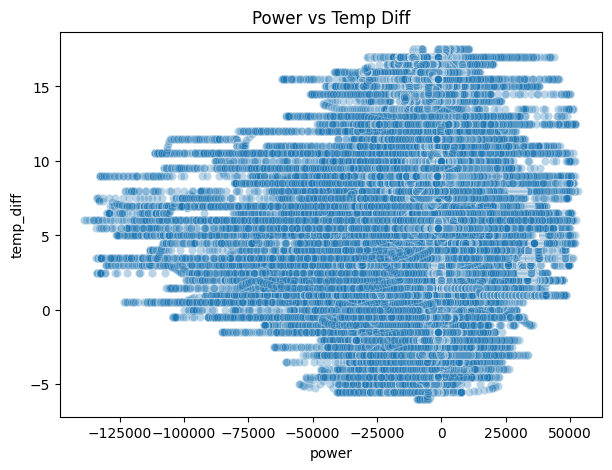

In [28]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=tripb_df["power"],
    y=tripb_df["temp_diff"],
    alpha=0.3
)

plt.title("Power vs Temp Diff")

plt.show()

전력 사용량이 증가할수록 temp_diff 분산도 함께 커지는 패턴 존재
→ 높은 전력 부하 상황에서 배터리 발열 증가 가능성 존재
음수 방향 power 영역에서 데이터 밀집
→ 실제 차량이 대부분 방전 기반 주행 상태였음을 의미
극단적인 음수 power 구간에서 temp_diff 증가 패턴 일부 존재
→ 고출력 방전 상황에서 배터리 열 스트레스 증가 가능성 존재
전체적으로 완벽한 선형관계는 아님
→ 배터리 온도는 단순 power뿐 아니라 냉각 시스템, 외기온, 주행 패턴 등의 영향을 함께 받는 것으로 해석 가능

# 변화율 분석

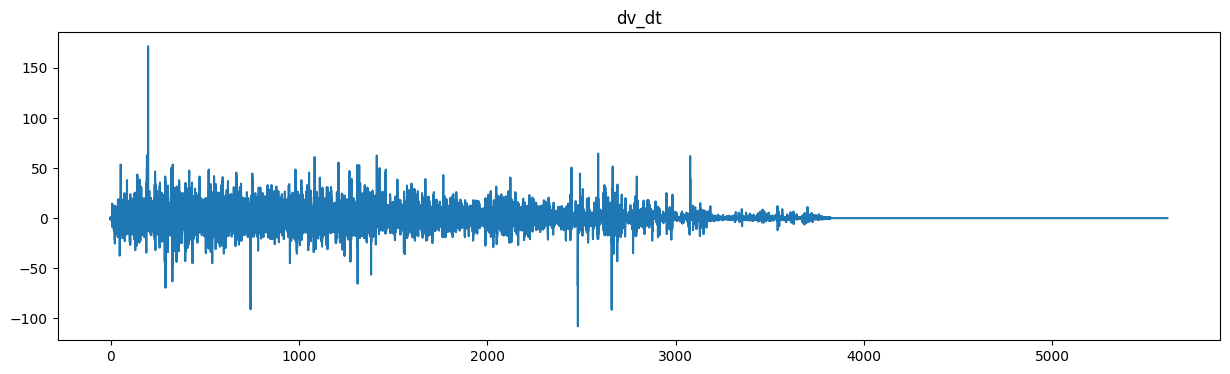

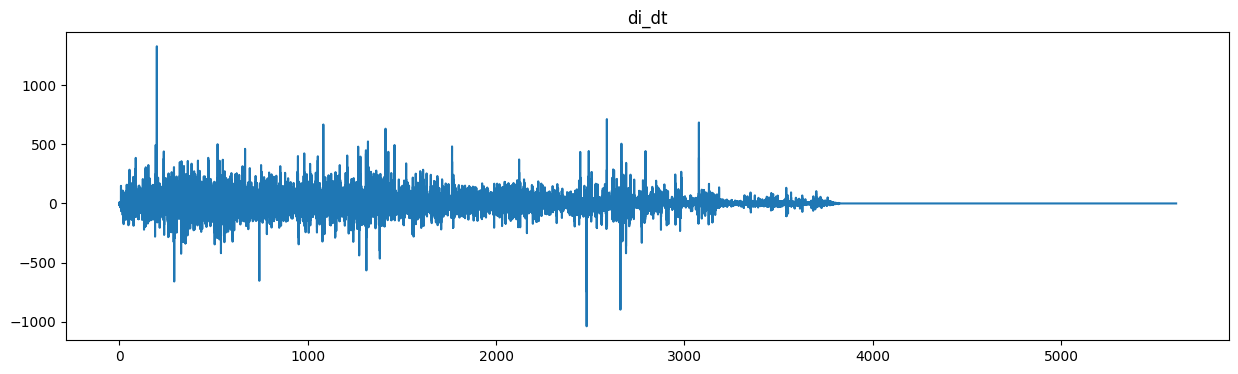

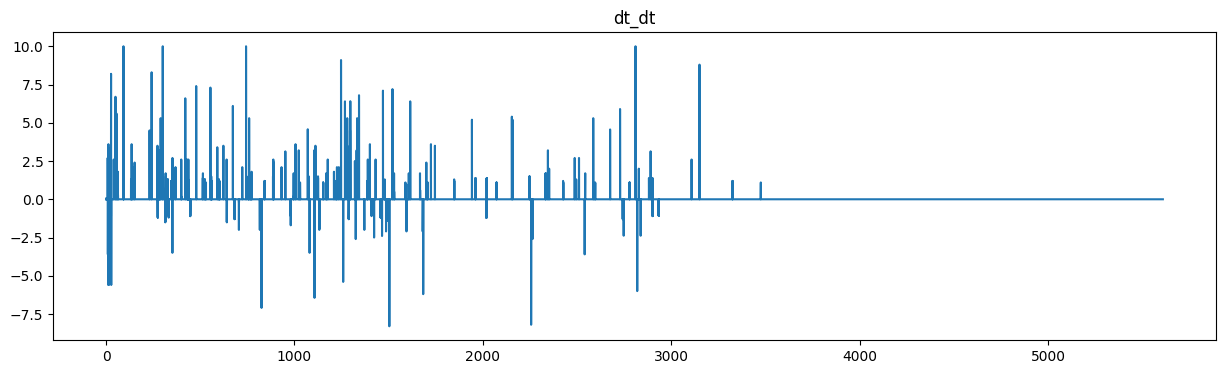

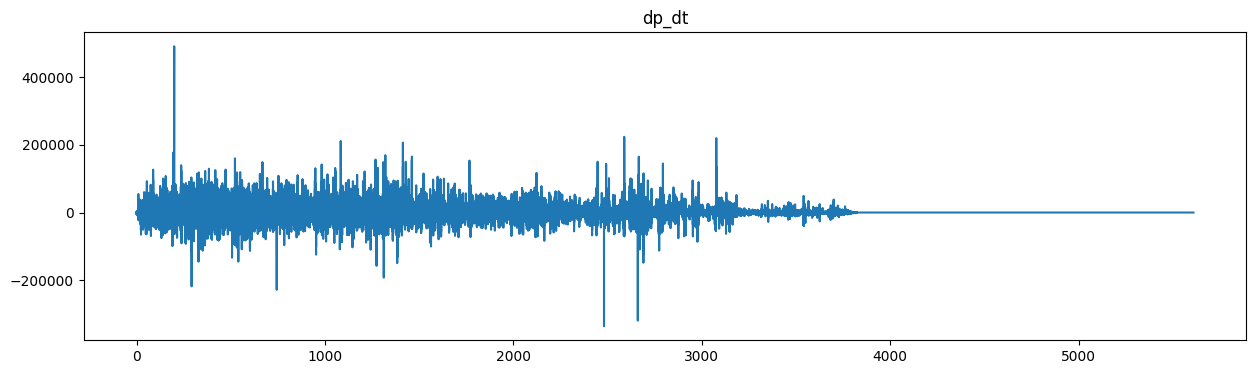

In [29]:
change_features = [
    "dv_dt",
    "di_dt",
    "dt_dt",
    "dp_dt"
]

for col in change_features:

    plt.figure(figsize=(15,4))

    plt.plot(
        tripb_df["time"],
        tripb_df[col]
    )

    plt.title(col)

    plt.show()

 6. dv_dt (전압 변화율)

* 일부 구간에서 극단적인 spike 존재
* 짧은 시간 내 전압 급변 발생
* 급가속, 순간 부하 증가, 회생제동 가능성 존재
* 전압 이상징후 탐지에 중요한 변수

7. di_dt (전류 변화율)

* 매우 큰 양수/음수 spike 다수 존재
* 짧은 시간 동안 전류 급변 발생
* 급가속 및 회생제동 전환 가능성 존재
* 배터리 스트레스 탐지 핵심 변수

 8. dt_dt (온도 변화율)

* 대부분 안정적이나 일부 급격한 변화 존재
* 순간 발열 또는 냉각 반응 가능성 존재
* Thermal anomaly 탐지 가능성 존재

9. dp_dt (전력 변화율)

* 극단적인 전력 변화 spike 존재
* 순간적인 부하 변화 발생
* 급가속·급감속·회생제동과 관련 가능
* 배터리 부하 스트레스 탐지 핵심 변수


# 정규성 체크

In [30]:
from scipy.stats import shapiro

for col in features:

    sample = (
        tripb_df[col]
        .dropna()
        .sample(5000)
    )

    stat, p = shapiro(sample)

    print(col)
    print("p-value:", p)
    print()

voltage
p-value: 1.115930609527282e-30

current
p-value: 5.130600396829527e-52

battery_temp
p-value: 8.890687835071884e-31

power
p-value: 6.785811541028805e-51

delta_v
p-value: 6.621697604283552e-69

delta_i
p-value: 1.2112601493610446e-68

delta_t_temp
p-value: 9.038682451857218e-96

delta_p
p-value: 4.102434582662329e-75

dv_dt
p-value: 1.2164563552491491e-71

di_dt
p-value: 9.326667597366017e-74

dt_dt
p-value: 3.1880036738014574e-95

dp_dt
p-value: 9.537345956366166e-67

temp_diff
p-value: 3.2317890668178943e-28



* 분석 결과 (Fact): 샤피로-윌크 검정 수행 결과, 전압·전류·온도 등 모든 주요 피처의 $p$-value가 0에 수렴하여 완벽한 비정규분포(Non-Gaussian) 상태임을 확인했습니다.

* EV 데이터의 특성 (Context): 전기차 주행 로그는 급가속, 급감속, 충전 패턴 등으로 인해 데이터가 한쪽으로 심하게 쏠리거나 극단적인 꼬리를 가지는 것이 물리적으로 당연한 현상입니다.

* 기존 기법의 한계 (Risk): 데이터가 정규분포를 따르지 않으므로, 논문 기반의 일반 Z-score와 $3\sigma$ 기준을 그대로 들이밀면 단순히 고속도로에서 추월하기 위해 엑셀을 밟은 '정상 차량'까지 '이상 차량'으로 오탐지(False Positive)할 확률이 매우 높아집니다.

* 최종 결론 및 액션 플랜 (Insight): 통계적 왜곡으로 인한 오탐지를 줄이고 알고리즘의 신뢰도를 확보하기 위해, 평균 기반의 $3\sigma$ 대신 중앙값을 활용하는 Robust Z-score를 도입하거나, PowerTransformer(Yeo-Johnson)를 통해 데이터를 정규분포 형태로 변환하는 전처리 고도화가 필수적입니다.

정규분포 형태를 띄지 않는다...

# Skewness / Kurtosis ( 데이터 왜도 및 첨도 보기 )

voltage
Skewness: -0.6711555383628866
Kurtosis: 0.5246123161337048

current
Skewness: -0.9762263264235729
Kurtosis: 6.351326008353262

battery_temp
Skewness: 0.260640492749191
Kurtosis: 0.0031392139082337955

power
Skewness: -0.583296209198806
Kurtosis: 4.839640042295574

delta_v
Skewness: 7.763587205626576
Kurtosis: 552.2022198169004

delta_i
Skewness: 1.2371528389247257
Kurtosis: 79.15730124337158

delta_t_temp
Skewness: -220.58591111993755
Kurtosis: 59454.75407970442

delta_p
Skewness: 1.1960288258456706
Kurtosis: 72.56950107961941

dv_dt
Skewness: 1.1047887674411807
Kurtosis: 58.12229645025242

di_dt
Skewness: 1.2845210812911567
Kurtosis: 74.24008282946005

dt_dt
Skewness: 25.38850422287664
Kurtosis: 2575.5281142226227

dp_dt
Skewness: 1.2702545627294848
Kurtosis: 65.8184129680642

temp_diff
Skewness: 0.45287944032061717
Kurtosis: 0.19033903532716456



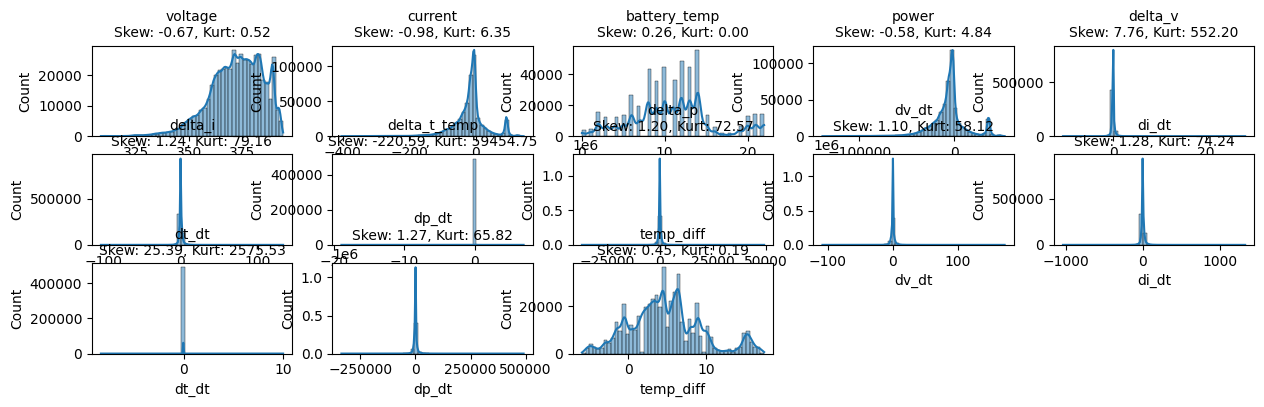

In [12]:
for col in features:

    print(col)

    print(
        "Skewness:",
        tripb_df[col].skew()
    )

    print(
        "Kurtosis:",
        tripb_df[col].kurtosis()
    )

    print()

## 첨도와 왜도 시각화
plt.figure(figsize=(15, 4)) 
for i, col in enumerate(features):

    plt.subplot(3, 5, i + 1)

    sns.histplot(
        tripb_df[col],
        kde=True,
        bins=50
    )

    plt.title(f"{col}\nSkew: {tripb_df[col].skew():.2f}, Kurt: {tripb_df[col].kurtosis():.2f}", fontsize=10)

| 값     | 의미          |
| ----- | ----------- |
| 0 근처  | 대칭(정규분포 느낌) |
| 양수(+) | 오른쪽 꼬리 김    |
| 음수(-) | 왼쪽 꼬리 김     |


| Feature        | Skewness 해석           | Kurtosis 해석            | 데이터 인사이트                                           |
| -------------- | --------------------- | ---------------------- | -------------------------------------------------- |
| `voltage`      | 약간 왼쪽으로 치우친 분포        | extreme outlier는 많지 않음 | 일부 낮은 전압 구간 존재, 전반적으로 안정적인 전압 상태 유지                |
| `current`      | 음수 방향(방전) 데이터 많음      | extreme 값 비교적 많음       | 고전류 사용 및 급가속·고부하 상황 가능성 존재                         |
| `battery_temp` | 거의 대칭에 가까움            | 정규분포 수준                | 배터리 온도는 비교적 안정적이며 BMS 및 냉각 시스템 정상 작동 가능성 존재        |
| `power`        | 음수 방향(방전) 사용량 많음      | extreme 값 존재           | 고출력 방전 및 배터리 부하 stress 가능성 존재                      |
| `delta_v`      | 매우 강한 오른쪽 치우침         | 극단적인 spike 매우 많음       | 순간적인 전압 급변 다수 발생, anomaly detection 핵심 feature 가능성 |
| `delta_i`      | 오른쪽 치우침 존재            | extreme outlier 다수 존재  | 전류 급변 패턴 존재, 급가속·회생제동 관련 가능성 존재                    |
| `delta_t_temp` | 일부 급격한 온도 변화 존재 가능    | spike 존재 가능성           | 순간 발열 또는 냉각 시스템 반응 가능성 존재                          |
| `delta_p`      | 전력 변화가 특정 방향으로 치우침 가능 | extreme spike 존재 가능    | 순간적인 배터리 부하 변화 가능성 존재                              |
| `dv_dt`        | 전압 변화율 spike 존재 가능    | 높은 첨도 가능성              | 짧은 시간 내 전압 급변 발생 가능성 존재                            |
| `di_dt`        | 전류 변화율 spike 존재 가능    | extreme 값 다수 존재 가능     | 급격한 부하 변화 및 배터리 stress 탐지 가능                       |
| `dt_dt`        | 일부 급격한 온도 변화 존재       | 상대적으로 적은 spike         | thermal anomaly 초기 탐지 가능성 존재                       |
| `dp_dt`        | 전력 변화율 급변 패턴 존재       | extreme spike 존재 가능    | 순간적인 부하 변화 탐지 가능                                   |
| `temp_diff`    | 비교적 안정적인 분포           | extreme 값 많지 않음        | 외기 대비 배터리 온도는 전반적으로 안정적인 상태 유지                     |


# 5. 이상치 처리 전략 결정

In [13]:
# 분석용 dataframe 복사
analysis_df = tripb_df.copy()

# 시간 역전 제거: delta_t는 양수여야 정상
analysis_df = analysis_df[analysis_df["delta_t"] > 0]

# 물리적으로 불가능한 센서 오류만 제거
analysis_df = analysis_df[
    (analysis_df["voltage"] > 0) &
    (analysis_df["battery_temp"] > -50) &
    (analysis_df["battery_temp"] < 100)
]

# 인덱스 정리
analysis_df = analysis_df.reset_index(drop=True)

print(analysis_df.shape)
analysis_df.head()

(491156, 18)


,time,source,voltage,current,battery_temp,ambient_temp,delta_t,delta_v,delta_i,delta_t_temp,delta_p,power,dv_dt,di_dt,dt_dt,dp_dt,mode,temp_diff
0,0.1,TripB21.csv,374.60,-17.90,7.0,1.5,0.1,0.00,0.00,0.0,0.0000,-6705.3400,0.0,0.0,0.0,0.000,Discharging,5.5
1,0.1,TripB14.csv,391.60,-1.10,3.0,3.0,0.1,0.00,0.00,0.0,0.0000,-430.7600,0.0,0.0,0.0,0.000,Discharging,0.0
2,0.1,TripB08.csv,381.59,-14.17,7.0,3.5,0.1,-0.01,0.03,0.0,11.5897,-5407.1303,-0.1,0.3,0.0,115.897,Discharging,3.5
3,0.1,TripB03.csv,383.30,-1.60,9.0,3.5,0.1,0.00,0.00,0.0,0.0000,-613.2800,0.0,0.0,0.0,0.000,Discharging,5.5
4,0.1,TripB11.csv,366.80,-10.60,14.0,4.0,0.1,0.00,0.00,0.0,0.0000,-3888.0800,0.0,0.0,0.0,0.000,Discharging,10.0


# 정규성 검정

In [14]:
from scipy.stats import shapiro

features = [
    "voltage",
    "current",
    "battery_temp",
    "power",
    "delta_v",
    "delta_i",
    "delta_t_temp",
    "delta_p",
    "dv_dt",
    "di_dt",
    "dt_dt",
    "dp_dt",
    "temp_diff"
]

normality_results = []

for col in features:
    sample = analysis_df[col].dropna()
    
    # Shapiro는 데이터가 너무 크면 민감하므로 최대 5000개 샘플링
    if len(sample) > 5000:
        sample = sample.sample(5000, random_state=42)
    
    stat, p_value = shapiro(sample)
    
    normality_results.append({
        "feature": col,
        "shapiro_stat": stat,
        "p_value": p_value,
        "normality_result": "정규성 가능" if p_value > 0.05 else "정규성 약함"
    })

normality_df = pd.DataFrame(normality_results)
normality_df

,feature,shapiro_stat,p_value,normality_result
0,voltage,0.970875,1.023264e-30,정규성 약함
1,current,0.897113,1.086725e-49,정규성 약함
2,battery_temp,0.969218,1.893307e-31,정규성 약함
3,power,0.906963,5.284115e-48,정규성 약함
4,delta_v,0.690672,4.135393e-70,정규성 약함
5,delta_i,0.686389,2.180624e-70,정규성 약함
6,delta_t_temp,0.018885,2.113423e-95,정규성 약함
7,delta_p,0.695005,7.962033e-70,정규성 약함
8,dv_dt,0.690672,4.135393e-70,정규성 약함
9,di_dt,0.686389,2.180624e-70,정규성 약함


Shapiro-Wilk 정규성 검정을 수행한 결과,
대부분의 feature에서 p-value가 0.05보다 매우 작게 나타났다.

이는 해당 변수들이 정규분포를 따르지 않는다는 의미이며,
특히 변화량(delta) 및 변화율(d/dt) 기반 feature에서 강한 비정규성이 확인되었다.

이는 실제 EV 운행 데이터에서 순간적인 spike와 extreme pattern이 존재함을 시사하며,
본 데이터가 anomaly detection 기반 접근에 적합한 특성을 가지고 있음을 의미한다.

# 7. Z-score 기반 이상도 계산

In [34]:
from scipy.stats import zscore
import numpy as np

for col in features:
    analysis_df[f"{col}_z"] = zscore(
        analysis_df[col].fillna(analysis_df[col].mean())
    )
    
    # 이상도 = Z-score 절댓값
    analysis_df[f"{col}_anomaly_score"] = analysis_df[f"{col}_z"].abs()

analysis_df.head()

,time,source,voltage,current,battery_temp,ambient_temp,delta_t,delta_v,delta_i,delta_t_temp,...,dv_dt_z,dv_dt_anomaly_score,di_dt_z,di_dt_anomaly_score,dt_dt_z,dt_dt_anomaly_score,dp_dt_z,dp_dt_anomaly_score,temp_diff_z,temp_diff_anomaly_score
0,0.1,TripB21.csv,374.60,-17.90,7.0,1.5,0.1,0.00,0.00,0.0,...,0.001777,0.001777,-0.000113,0.000113,-0.019343,0.019343,-0.000129,0.000129,0.156034,0.156034
1,0.1,TripB14.csv,391.60,-1.10,3.0,3.0,0.1,0.00,0.00,0.0,...,0.001777,0.001777,-0.000113,0.000113,-0.019343,0.019343,-0.000129,0.000129,-1.029817,1.029817
2,0.1,TripB08.csv,381.59,-14.17,7.0,3.5,0.1,-0.01,0.03,0.0,...,-0.029668,0.029668,0.011564,0.011564,-0.019343,0.019343,0.012557,0.012557,-0.275184,0.275184
3,0.1,TripB03.csv,383.30,-1.60,9.0,3.5,0.1,0.00,0.00,0.0,...,0.001777,0.001777,-0.000113,0.000113,-0.019343,0.019343,-0.000129,0.000129,0.156034,0.156034
4,0.1,TripB11.csv,366.80,-10.60,14.0,4.0,0.1,0.00,0.00,0.0,...,0.001777,0.001777,-0.000113,0.000113,-0.019343,0.019343,-0.000129,0.000129,1.126276,1.126276


# 8. Pseudo-label 생성

In [35]:
z_cols = [f"{col}_z" for col in features]

analysis_df["pseudo_label"] = (
    (analysis_df[z_cols].abs() > 3).any(axis=1)
).astype(int)

analysis_df["anomaly_feature_count"] = (
    (analysis_df[z_cols].abs() > 3).sum(axis=1)
)

print(analysis_df["pseudo_label"].value_counts())
print(analysis_df["pseudo_label"].value_counts(normalize=True) * 100)

pseudo_label
0    470704
1     20452
Name: count, dtype: int64
pseudo_label
0    95.835946
1     4.164054
Name: proportion, dtype: float64


0 (정상 데이터): 470,704건 (95.84%)
1 (이상 데이터): 20,452건 (4.16%)

"논문 기반의 3시그마 규칙으로 Pseudo-label을 생성한 결과, 전체 데이터의 **4.16%**가 이상치로 분류되었다. 가우시안 분포의 이론적 이상치 비율인 0.27%보다 약 15배 높은 수치이다. 이는 앞서 왜도와 첨도 분석에서 확인했듯, EV 주행 데이터 특유의 고첨도 변수들로 인해 일반 Z-score 모델이 정상적인 급가속/회생제동 구간을 이상 상태로 과도하게 오탐지(False Positive)하고 있음을 정량적으로 증명한다."

# 9. 어떤 feature에서 이상이 많이 발생했는지 확인

In [ ]:
feature_anomaly_summary = []

for col in features:
    count = (analysis_df[f"{col}_z"].abs() > 3).sum()
    ratio = count / len(analysis_df) * 100
    
    feature_anomaly_summary.append({
        "feature": col,
        "anomaly_count": count,
        "anomaly_ratio_percent": ratio
    })

feature_anomaly_df = pd.DataFrame(feature_anomaly_summary)
feature_anomaly_df = feature_anomaly_df.sort_values(
    "anomaly_ratio_percent",
    ascending=False
)

feature_anomaly_df

,feature,anomaly_count,anomaly_ratio_percent
4,delta_v,10266,2.090171
8,dv_dt,10266,2.090171
7,delta_p,10255,2.087931
11,dp_dt,10255,2.087931
5,delta_i,10105,2.057391
9,di_dt,10105,2.057391
1,current,5715,1.163581
3,power,5272,1.073386
0,voltage,3696,0.752510
10,dt_dt,1030,0.209709


* delta_v와 dv_dt, delta_p와 dp_dt, delta_i와 di_dt는 소수점 아래까지 똑같아, 둘 중 하나는 지워도 상관 없음

1. 배터리 이상치의 주범은 '전기의 변화량' 
이상치 비율 탑 3는 모두 delta_v(전압 변화), delta_p(전력 변화), delta_i(전류 변화) 관련 피처들입니다. 약 2%대 비율을 차지하죠.

의미: 아까 첨도 분석에서 delta_v 첨도가 552로 엄청나게 뾰족했음. 평소엔 얌전하다가 엑셀을 밟거나 센서가 튈 때 순간적인 변화량이 통계적 선(3시그마)을 가장 자주 넘나들며 전체 이상치 비율을 4.16%까지 끌어올린 일등 공신이라는 뜻입니다.


종합 결론: 전체 데이터의 4.16%가 이상치로 라벨링된 배경에는 '전압·전류·전력의 순간적인 변화량(Delta)' 피처들의 영향이 지대적이었음을 확인하였습니다. 단, 변화량($\Delta$)과 변화율($\_dt$)의 에러 검출 플래그가 100% 일치하므로 다중공선성 제거를 위한 피처 드롭(Feature Drop)이 선행되어야 하며, 온도 지표의 기여도를 높이기 위해선 절댓값 기준이 아닌 이동 평균 기반의 탐지 방식 체계 수정을 고려해봐야 할 것 같습니다.

# 10. Pearson Correlation 분석

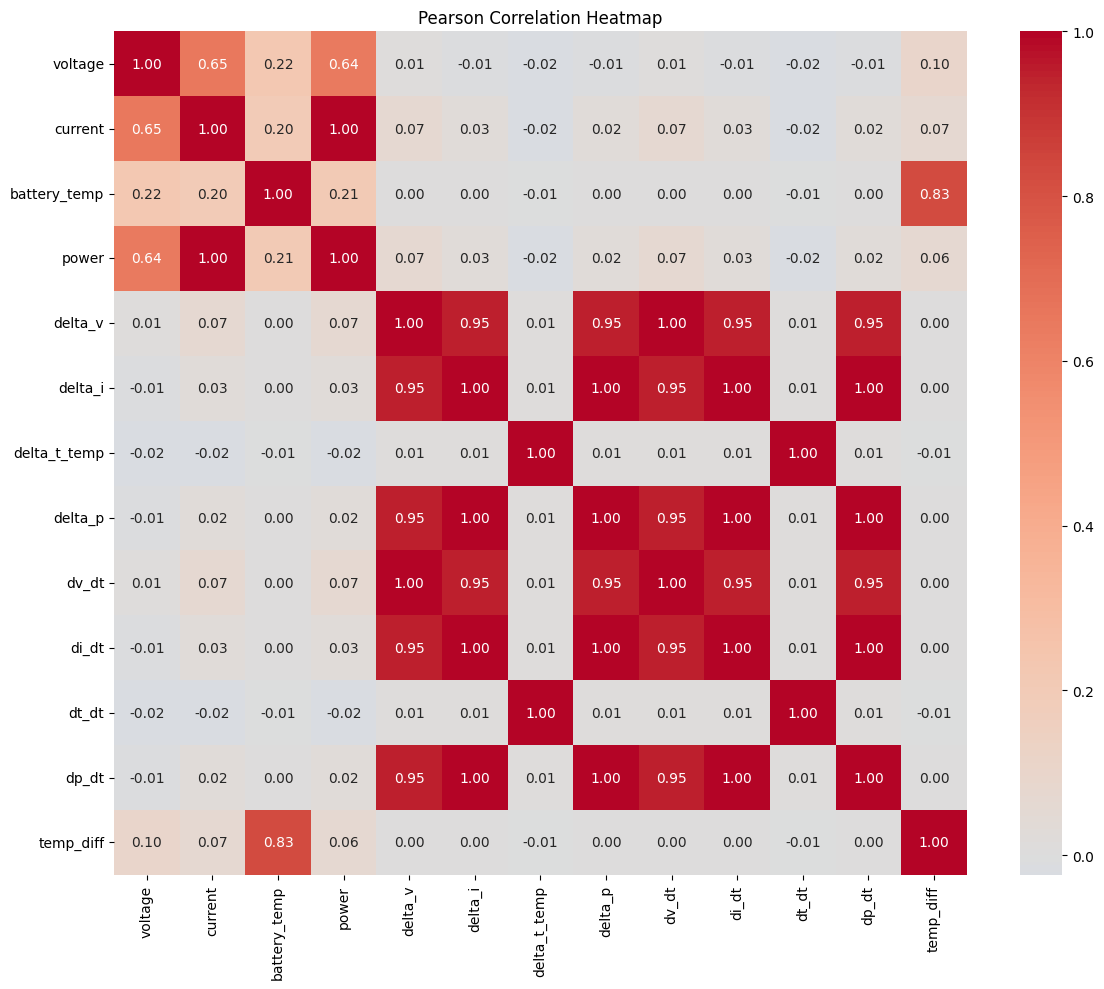

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = analysis_df[features].corr(method="pearson")

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()

1. 피처를 고르는 3가지 전처리 기준

기준 ①: 상관계수가 0.95~1.00인 변수는 '쌍둥이'이므로 하나만 남긴다.

둘이 완벽하게 똑같이 움직인다면, 데이터 분석 관점에서는 굳이 두 개를 다 쓸 필요가 없습니다. 하나는 지워야 모델이 가벼워지고 정확해집니다.

기준 ②: 단순 차이(delta)보다 시간 개념이 들어간 변화율(_dt)을 살린다.

delta_v와 dv_dt는 쌍둥이입니다. 이때 데이터 엔지니어는 '시간당 얼마나 변했는지'라는 물리적 의미가 더 정확한 dv_dt (변화율)을 선택하는 것이 정석입니다.

기준 ③: 상관계수가 0에 가까운 것들은 '서로 다른 특기'를 가졌으니 둘 다 살린다.

예를 들어 voltage(전압 크기)와 dv_dt(전압이 변하는 속도)는 상관계수가 0에 가깝습니다. 즉, 전압이 높은 것과 전압이 튀는 것은 전혀 다른 신호이므로, 둘 다 감시팀 멤버로 뽑아야 다각도로 이상 징후를 잡을 수 있습니다.

### 무엇을 버릴지

❌ 과감히 버릴 피처 (6개)
delta_v, delta_i, delta_t_temp, delta_p

➔ 이유: _dt 시리즈와 100% 똑같은 쌍둥이들입니다.

power, dp_dt

➔ 이유: current 및 di_dt와 소수점까지 똑같이 움직이므로 정보 중복입니다.

### 무엇을 살릴지

| 구 분 | 선택된 피처 | 이 피처가 담당하는 감시 역할 |
| :--- | :--- | :--- |
| **현재 상태**<br>(State) | **`voltage`** (전압)<br>**`current`** (전류)<br>**`temp_diff`** (보정 온도) | 배터리가 지금 과충전 상태인지, 과하게 무리를 하고 있는지, 열을 받고 있는지 절대적인 크기를 감시합니다. |
| **변화 속도**<br>(Dynamics) | **`dv_dt`** (전압 변화율)<br>**`di_dt`** (전류 변화율)<br>**`dt_dt`** (온도 변화율) | 배터리 값이 순간적으로 얼마나 급격하게 출렁거리고 요동치는지 '불안정성'을 감시합니다. |

# Z - SCORE 생성

In [ ]:
from scipy.stats import zscore
import pandas as pd
import numpy as np

# 분석에 사용할 feature
features = [
    "voltage",
    "current",
    "battery_temp",
    "power",
    "delta_v",
    "delta_i",
    "delta_t_temp",
    "delta_p",
    "dv_dt",
    "di_dt",
    "dt_dt",
    "dp_dt",
    "temp_diff"
]

# 분석용 데이터프레임 복사
analysis_df = tripb_df.copy()

# 결측치가 있으면 평균으로 대체
analysis_df[features] = analysis_df[features].fillna(
    analysis_df[features].mean()
)

# 1. 각 feature별 Z-score 계산
for col in features:
    analysis_df[f"{col}_z"] = zscore(analysis_df[col])

# 2. 이상도 계산: Ai = |Zi|
for col in features:
    analysis_df[f"{col}_anomaly_score"] = analysis_df[f"{col}_z"].abs()

# 3. 3σ 기준 feature별 이상 여부 생성
for col in features:
    analysis_df[f"{col}_is_anomaly"] = (
        analysis_df[f"{col}_z"].abs() > 3
    ).astype(int)

# 4. 하나라도 3σ를 넘으면 pseudo-label = 1
anomaly_cols = [f"{col}_is_anomaly" for col in features]

analysis_df["pseudo_label"] = (
    analysis_df[anomaly_cols].sum(axis=1) > 0
).astype(int)

# 5. 한 row에서 몇 개 feature가 이상인지 계산
analysis_df["anomaly_ffrom scipy.stats import zscore
import pandas as pd
import numpy as np

# 분석에 사용할 feature
features = [
    "voltage",
    "current",
    "battery_temp",
    "power",
    "delta_v",
    "delta_i",
    "delta_t_temp",
    "delta_p",
    "dv_dt",
    "di_dt",
    "dt_dt",
    "dp_dt",
    "temp_diff"
]

# 분석용 데이터프레임 복사
analysis_df = tripb_df.copy()

# 결측치가 있으면 평균으로 대체
analysis_df[features] = analysis_df[features].fillna(
    analysis_df[features].mean()
)

# 1. 각 feature별 Z-score 계산
for col in features:
    analysis_df[f"{col}_z"] = zscore(analysis_df[col])

# 2. 이상도 계산: Ai = |Zi|
for col in features:
    analysis_df[f"{col}_anomaly_score"] = analysis_df[f"{col}_z"].abs()

# 3. 3σ 기준 feature별 이상 여부 생성
for col in features:
    analysis_df[f"{col}_is_anomaly"] = (
        analysis_df[f"{col}_z"].abs() > 3
    ).astype(int)

# 4. 하나라도 3σ를 넘으면 pseudo-label = 1
anomaly_cols = [f"{col}_is_anomaly" for col in features]

analysis_df["pseudo_label"] = (
    analysis_df[anomaly_cols].sum(axis=1) > 0
).astype(int)

# 5. 한 row에서 몇 개 feature가 이상인지 계산
analysis_df["anomaly_feature_count"] = analysis_df[anomaly_cols].sum(axis=1)

# 결과 확인
analysis_df.head(10)eature_count"] = analysis_df[anomaly_cols].sum(axis=1)

# 결과 확인
analysis_df.head(10)

,time,source,voltage,current,battery_temp,ambient_temp,delta_t,delta_v,delta_i,delta_t_temp,...,delta_i_is_anomaly,delta_t_temp_is_anomaly,delta_p_is_anomaly,dv_dt_is_anomaly,di_dt_is_anomaly,dt_dt_is_anomaly,dp_dt_is_anomaly,temp_diff_is_anomaly,pseudo_label,anomaly_feature_count
795321,0.0,TripB15.csv,391.3,-1.30000,9.0,2.0,-3821.9,28.5,3.20000,-4.0,...,0,1,0,0,0,0,0,0,1,2
943047,0.0,TripB27.csv,374.9,-1.30000,1.0,1.0,-804.9,28.1,3.00000,-14.0,...,0,1,0,0,0,0,0,0,1,2
757101,0.0,TripB14.csv,391.6,-1.10000,3.0,3.0,-354.4,24.8,81.70000,-17.0,...,1,1,1,0,0,0,0,0,1,4
881475,0.0,TripB21.csv,374.6,-17.90000,7.0,1.5,-1402.8,-2.0,-14.20000,-5.0,...,1,1,1,0,0,0,0,0,1,4
693533,0.0,TripB10.csv,391.5,-1.40000,2.0,2.5,-5610.1,2.3,-94.30000,-12.0,...,1,1,1,0,0,0,0,0,1,4
467701,0.0,TripB01.csv,388.8,-19.06128,7.0,8.5,-1672.1,12.4,-16.62128,-19.0,...,1,1,1,0,0,0,0,0,1,4
721300,0.0,TripB12.csv,388.8,-8.50000,22.0,7.5,-753.3,28.4,-5.30000,7.0,...,0,1,0,0,0,0,0,0,1,2
753556,0.0,TripB13.csv,376.4,-14.40000,20.0,6.0,-3225.5,3.6,-10.80000,0.0,...,1,0,1,0,0,0,0,0,1,3
516332,0.0,TripB03.csv,383.3,-1.60000,9.0,3.5,-1611.2,2.6,3.30000,-6.0,...,0,1,0,0,0,0,0,0,1,2
914998,0.0,TripB24.csv,373.2,-6.00000,10.0,6.5,-1113.2,2.5,-1.60000,0.0,...,0,0,0,0,0,0,0,0,1,1


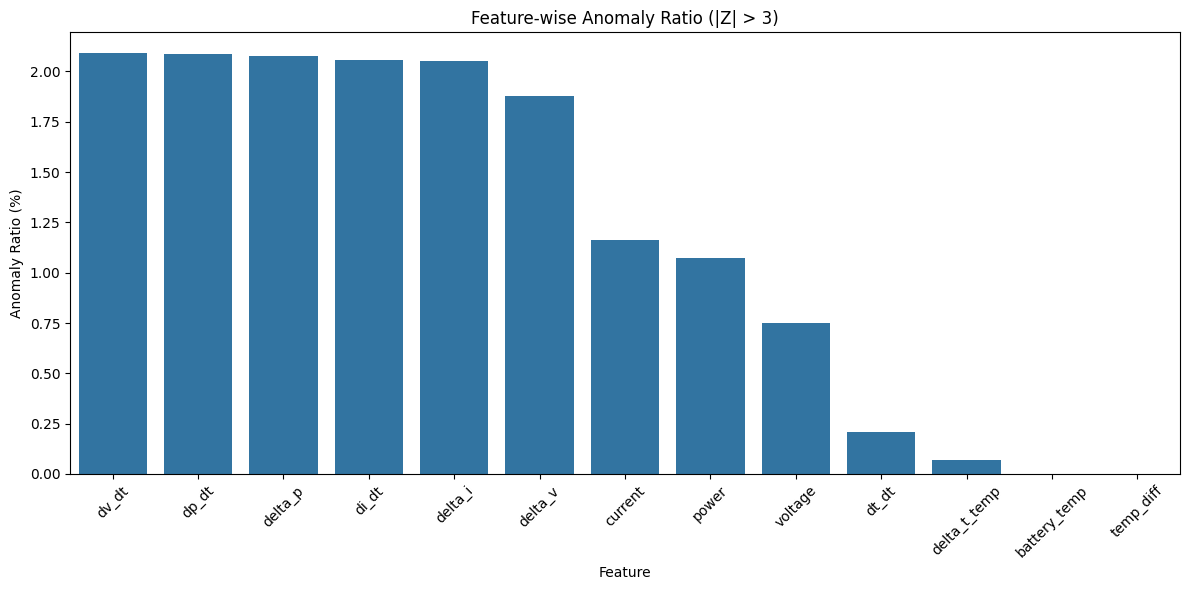

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Feature별 이상 비율 시각화
# -----------------------------

plt.figure(figsize=(12, 6))

sns.barplot(
    data=feature_anomaly_df,
    x="feature",
    y="anomaly_ratio_percent"
)

plt.xticks(rotation=45)

plt.ylabel("Anomaly Ratio (%)")
plt.xlabel("Feature")

plt.title("Feature-wise Anomaly Ratio (|Z| > 3)")

plt.tight_layout()
plt.show()

# feature별 이상 발생 개수와 비율 확인

In [39]:
feature_anomaly_summary = []

for col in features:
    count = analysis_df[f"{col}_is_anomaly"].sum()
    ratio = count / len(analysis_df) * 100
    
    feature_anomaly_summary.append({
        "feature": col,
        "anomaly_count": count,
        "anomaly_ratio_percent": round(ratio, 3)
    })

feature_anomaly_df = pd.DataFrame(feature_anomaly_summary)

feature_anomaly_df = feature_anomaly_df.sort_values(
    by="anomaly_ratio_percent",
    ascending=False
)

feature_anomaly_df

,feature,anomaly_count,anomaly_ratio_percent
8,dv_dt,10266,2.090
11,dp_dt,10256,2.088
7,delta_p,10195,2.076
9,di_dt,10105,2.057
5,delta_i,10076,2.051
4,delta_v,9215,1.876
1,current,5715,1.164
3,power,5272,1.073
0,voltage,3696,0.752
10,dt_dt,1030,0.210


# 전체 pseudo-label 비율 확인

In [46]:
pseudo_summary = analysis_df["pseudo_label"].value_counts().reset_index()
pseudo_summary.columns = ["pseudo_label", "count"]

pseudo_summary["ratio_percent"] = (
    pseudo_summary["count"] / len(analysis_df) * 100
).round(3)

pseudo_summary

,pseudo_label,count,ratio_percent
0,0,470707,95.831
1,1,20477,4.169


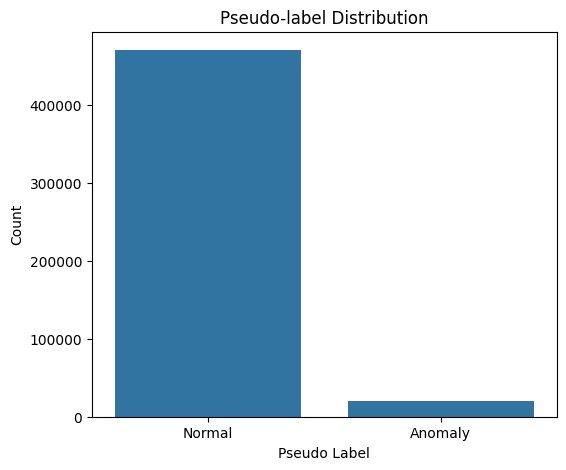

In [41]:
# -----------------------------
# 2. Pseudo-label 분포 시각화
# -----------------------------

plt.figure(figsize=(6, 5))

sns.countplot(
    data=analysis_df,
    x="pseudo_label"
)

plt.title("Pseudo-label Distribution")

plt.xlabel("Pseudo Label")
plt.ylabel("Count")

plt.xticks(
    [0, 1],
    ["Normal", "Anomaly"]
)

plt.show()

# 이상 데이터만 따로 보기

In [47]:
anomaly_df = analysis_df[analysis_df["pseudo_label"] == 1]

anomaly_df[
    [
        "time",
        "source",
        "voltage",
        "current",
        "battery_temp",
        "power",
        "temp_diff",
        "anomaly_feature_count",
        "pseudo_label"
    ]
].head(20)

,time,source,voltage,current,battery_temp,power,temp_diff,anomaly_feature_count,pseudo_label
795321,0.0,TripB15.csv,391.3,-1.30000,9.0,-508.690000,7.0,2,1
943047,0.0,TripB27.csv,374.9,-1.30000,1.0,-487.370000,0.0,2,1
757101,0.0,TripB14.csv,391.6,-1.10000,3.0,-430.760000,0.0,4,1
881475,0.0,TripB21.csv,374.6,-17.90000,7.0,-6705.340000,5.5,4,1
693533,0.0,TripB10.csv,391.5,-1.40000,2.0,-548.100000,-0.5,4,1
467701,0.0,TripB01.csv,388.8,-19.06128,7.0,-7411.025664,-1.5,4,1
721300,0.0,TripB12.csv,388.8,-8.50000,22.0,-3304.800000,14.5,2,1
753556,0.0,TripB13.csv,376.4,-14.40000,20.0,-5420.160000,14.0,3,1
516332,0.0,TripB03.csv,383.3,-1.60000,9.0,-613.280000,5.5,2,1
914998,0.0,TripB24.csv,373.2,-6.00000,10.0,-2239.200000,3.5,1,1


# Feature별 Z-score 분포

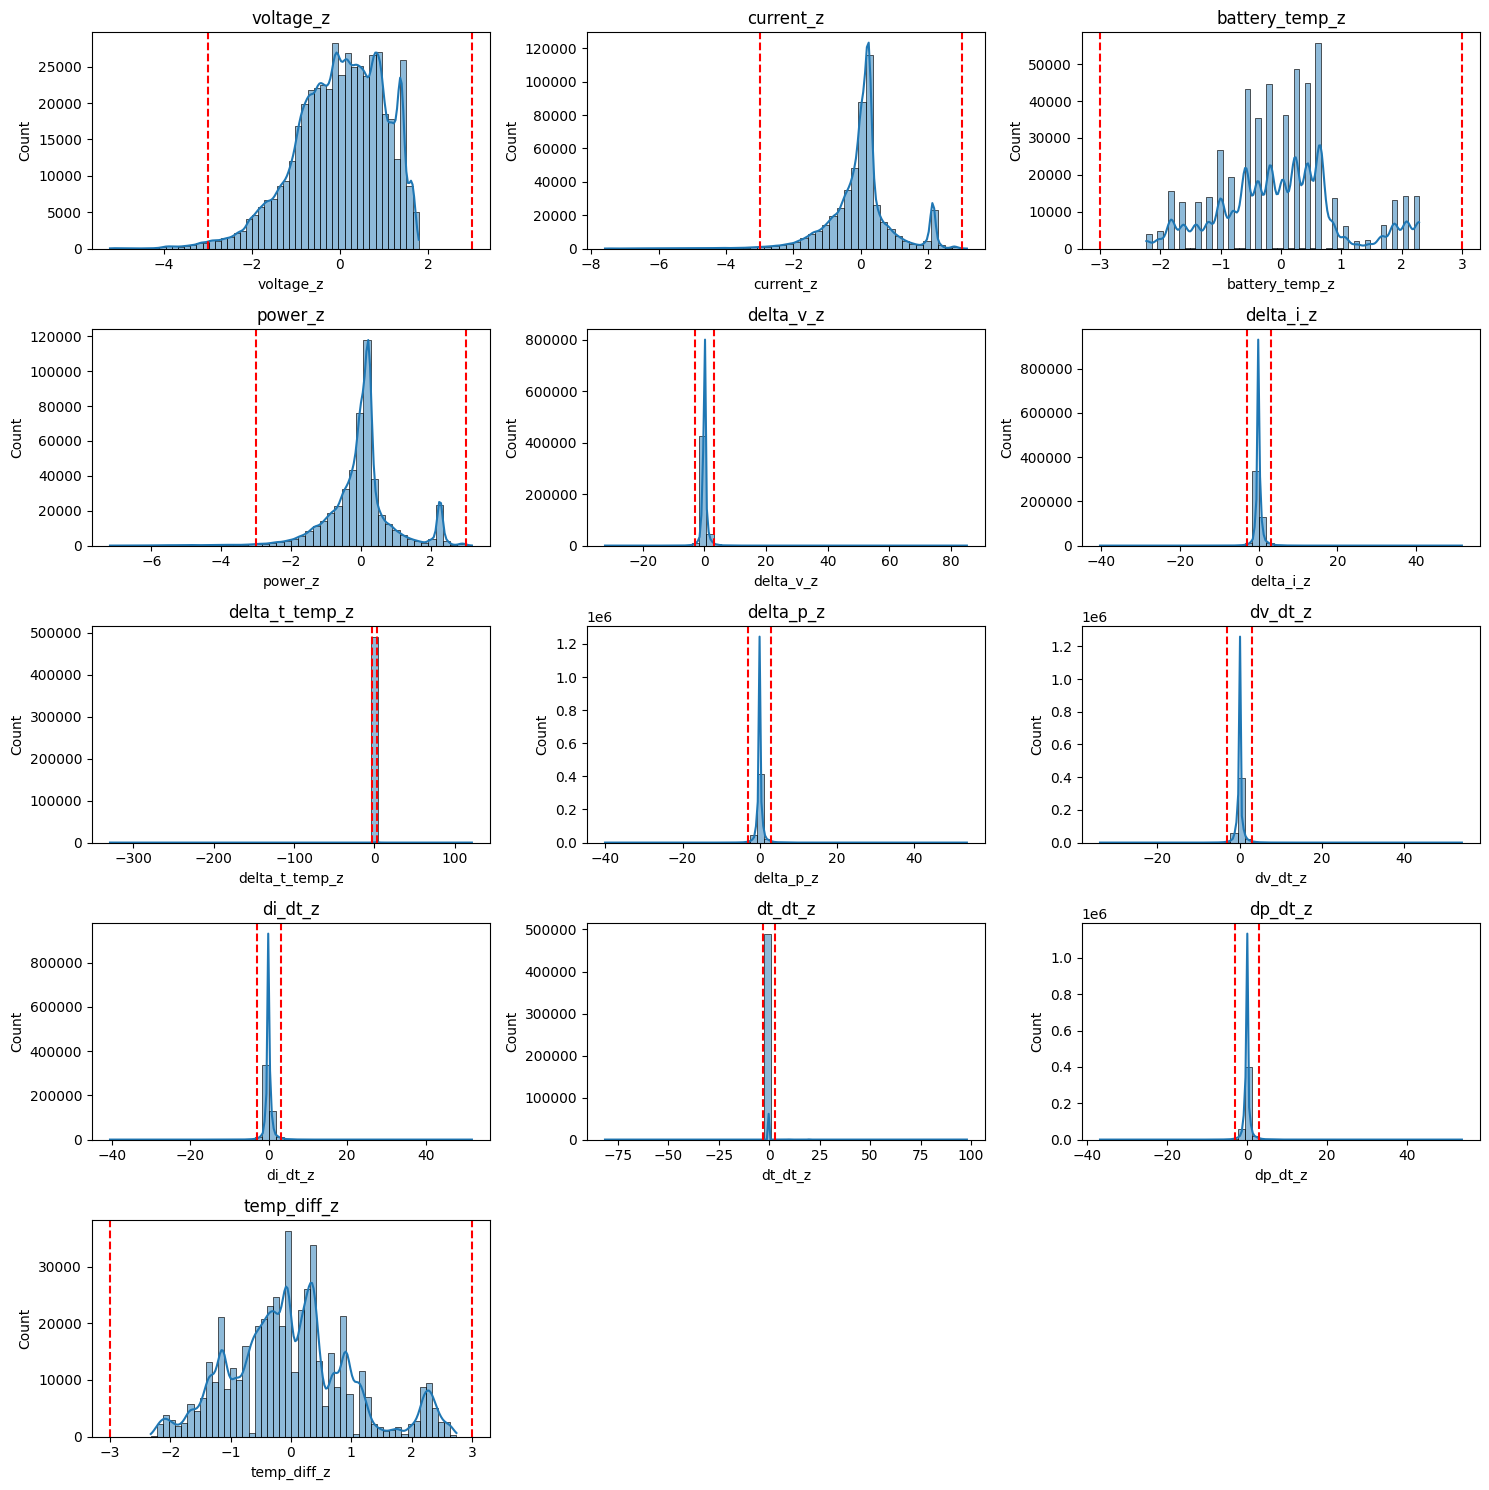

In [42]:
# -----------------------------
# 3. Feature별 Z-score 분포
# -----------------------------

z_cols = [f"{col}_z" for col in features]

n_cols = 3
n_rows = int(np.ceil(len(z_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, n_rows * 3)
)

axes = axes.flatten()

for i, col in enumerate(z_cols):

    sns.histplot(
        analysis_df[col],
        bins=50,
        kde=True,
        ax=axes[i]
    )

    axes[i].axvline(
        x=3,
        color='red',
        linestyle='--'
    )

    axes[i].axvline(
        x=-3,
        color='red',
        linestyle='--'
    )

    axes[i].set_title(col)

# 남는 subplot 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 4. 시간 흐름에 따른 이상 탐지

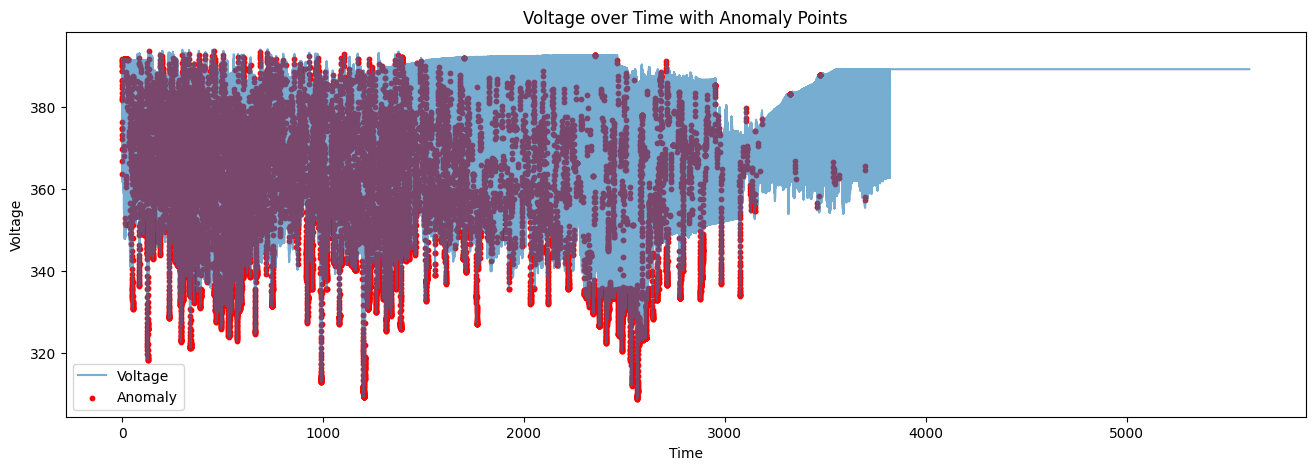

In [43]:
# -----------------------------
# 4. 시간 흐름에 따른 이상 탐지
# -----------------------------

plt.figure(figsize=(16, 5))

# 전체 voltage
plt.plot(
    analysis_df["time"],
    analysis_df["voltage"],
    alpha=0.6,
    label="Voltage"
)

# anomaly만 빨간색 표시
anomaly_points = analysis_df[
    analysis_df["pseudo_label"] == 1
]

plt.scatter(
    anomaly_points["time"],
    anomaly_points["voltage"],
    color="red",
    s=10,
    label="Anomaly"
)

plt.title("Voltage over Time with Anomaly Points")

plt.xlabel("Time")
plt.ylabel("Voltage")

plt.legend()

plt.show()

언제
어디서
얼마나 자주
얼마나 심하게
배터리 스트레스가 발생하는지

1. 전압 이상치가 특정 구간에 집중적으로 발생
그래프를 보면 빨간 점(이상치)가 전체 구간에 존재함. 특히 약 0~1500 sec, 약 2300~3100 sec 구간에서 매우 밀집되어 있음. 
이는 해당 시간대에 배터리가 정상 범위를 벗어나는 전압 변동을 반복적으로 경험했다는 의미로 ( 급가속, 급부하, 회생제동 전환, 순간 고출력 사용 등이 집주오디었을 가능성이 높다 )

2. 전압 급락 현상이 반복적으로 관측됨 
정상적인 EV 배터리 전압은 비교적 완만하게 변해야하는데 그래프에서는 390V근처에서 순간적으로 320V이하까지 급락하는 패턴이 반복 => 배터리가 순간적으로 큰 stress를 받음을 의미 


# 5. 이상 데이터의 anomaly score 분포

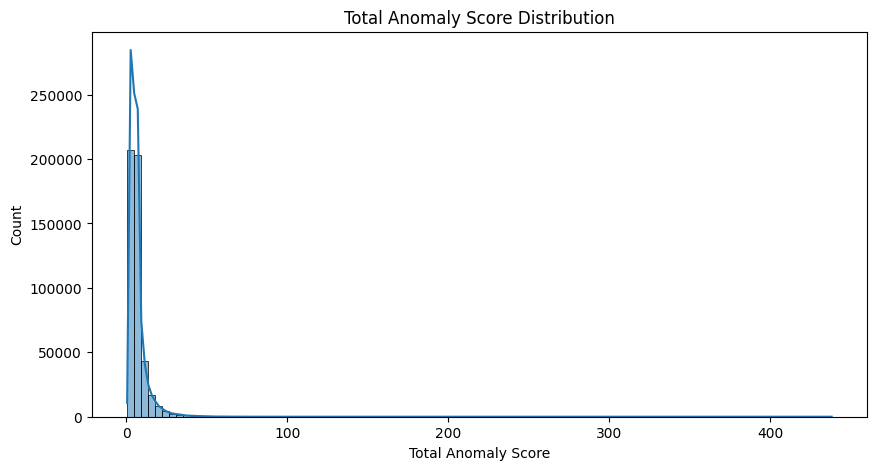

In [44]:
# -----------------------------
# 5. 이상 데이터의 anomaly score 분포
# -----------------------------

analysis_df["total_anomaly_score"] = analysis_df[
    [f"{col}_anomaly_score" for col in features]
].sum(axis=1)

plt.figure(figsize=(10, 5))

sns.histplot(
    analysis_df["total_anomaly_score"],
    bins=100,
    kde=True
)

plt.title("Total Anomaly Score Distribution")

plt.xlabel("Total Anomaly Score")
plt.ylabel("Count")

plt.show()

# 6. 이상 feature 개수 분포

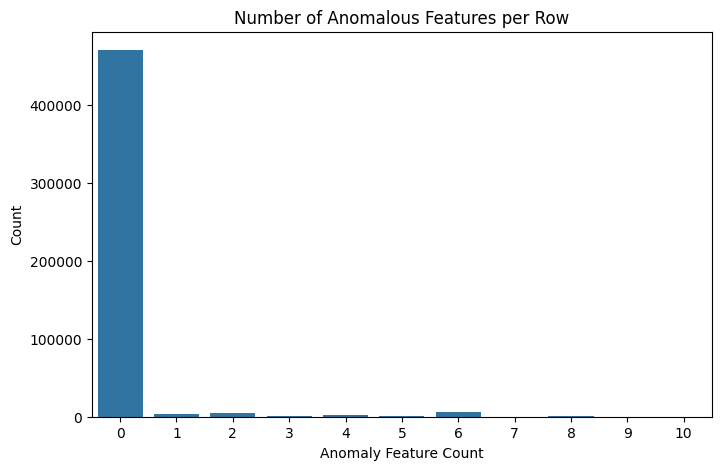

In [45]:
# -----------------------------
# 6. 이상 feature 개수 분포
# -----------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    x=analysis_df["anomaly_feature_count"]
)

plt.title("Number of Anomalous Features per Row")

plt.xlabel("Anomaly Feature Count")
plt.ylabel("Count")

plt.show()

## Robust Z-Score 

Z-score가 평균에서 얼마나 떨어졌는가? 라면 Robust z-SCORE는 중앙값에서 얼마나 떨어졌는가? 
Robust Z = 0.6745 × (값 - 중앙값) / MAD

In [48]:
import numpy as np
import pandas as pd

robust_df = analysis_df.copy()

for col in features:
    median = robust_df[col].median()
    mad = np.median(np.abs(robust_df[col] - median))
    
    if mad == 0:
        robust_df[f"{col}_robust_z"] = 0
    else:
        robust_df[f"{col}_robust_z"] = 0.6745 * (robust_df[col] - median) / mad
    
    robust_df[f"{col}_robust_anomaly_score"] = robust_df[f"{col}_robust_z"].abs()
    robust_df[f"{col}_robust_is_anomaly"] = (
        robust_df[f"{col}_robust_z"].abs() > 3
    ).astype(int)

robust_anomaly_cols = [
    f"{col}_robust_is_anomaly" for col in features
]

robust_df["robust_pseudo_label"] = (
    robust_df[robust_anomaly_cols].sum(axis=1) > 0
).astype(int)

robust_df["robust_anomaly_feature_count"] = (
    robust_df[robust_anomaly_cols].sum(axis=1)
)

robust_df["robust_pseudo_label"].value_counts(normalize=True) * 100

robust_pseudo_label
0    65.238485
1    34.761515
Name: proportion, dtype: float64

In [49]:
comparison = pd.DataFrame({
    "method": ["z_score", "robust_z_score"],
    "anomaly_count": [
        analysis_df["pseudo_label"].sum(),
        robust_df["robust_pseudo_label"].sum()
    ],
    "anomaly_ratio_percent": [
        analysis_df["pseudo_label"].mean() * 100,
        robust_df["robust_pseudo_label"].mean() * 100
    ]
})

comparison

,method,anomaly_count,anomaly_ratio_percent
0,z_score,20477,4.168906
1,robust_z_score,170743,34.761515


Robust Z-score를 같이 써보자고 한 이유는 너희 데이터 분포가 일반 Z-score에 불리한 형태였기 때문이야.

일반 Z-score는 평균(mean)과 표준편차(std)를 기준으로 계산해. 그런데 너희 데이터는 왜도와 첨도가 높고, delta_v, delta_i, dv_dt, di_dt, dp_dt처럼 spike가 많은 feature가 있었어. 이런 극단값이 많으면 평균과 표준편차 자체가 흔들려서, 이상도를 안정적으로 판단하기 어려울 수 있어.

반면 Robust Z-score는 중앙값(median)과 MAD를 사용해. 그래서 극단값의 영향을 덜 받고, long-tail이나 spike가 많은 데이터에서 더 안정적으로 이상 후보를 볼 수 있어.

# PCA

복잡한 feature들을 핵심 패턴 몇 개로 압축 
원래 데이터 13차원 공간 -> 2~3개의 핵심 축으로 압축 

In [50]:
pca_features = [
    "voltage",
    "current",
    "battery_temp",
    "power",

    "delta_v",
    "delta_i",
    "delta_t_temp",
    "delta_p",

    "dv_dt",
    "di_dt",
    "dt_dt",
    "dp_dt",

    "temp_diff"
]

In [51]:
from sklearn.preprocessing import StandardScaler

X = analysis_df[pca_features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [52]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [53]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "pseudo_label": analysis_df["pseudo_label"]
})

In [54]:
print(
    pca.explained_variance_ratio_
)

print(
    "Total Explained Variance:",
    pca.explained_variance_ratio_.sum()
)

[0.44518467 0.20724894]
Total Explained Variance: 0.6524336079895571


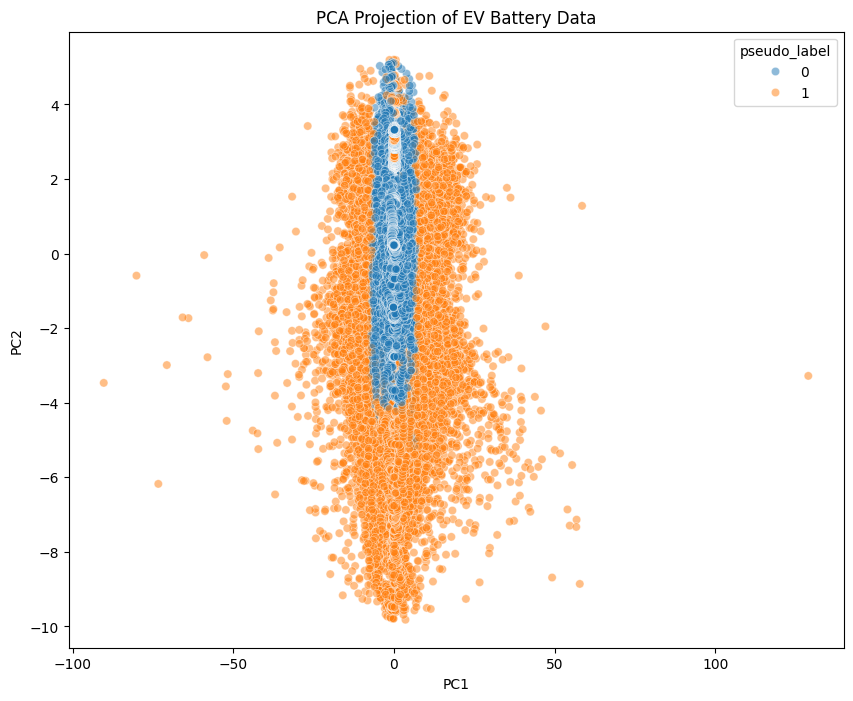

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="pseudo_label",
    alpha=0.5
)

plt.title("PCA Projection of EV Battery Data")

plt.show()

In [56]:
loading_df = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=pca_features
)

loading_df

,PC1,PC2
voltage,0.005746,0.481307
current,0.026009,0.558997
battery_temp,0.003592,0.306385
power,0.026121,0.557644
delta_v,0.392448,0.003011
delta_i,0.412335,-0.021290
delta_t_temp,-0.009833,-0.007064
delta_p,0.411960,-0.021813
dv_dt,0.405697,0.002341
di_dt,0.412524,-0.021234


## 전체 PCA 수행

In [61]:
from sklearn.decomposition import PCA

pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

In [62]:
explained_variance = pca_full.explained_variance_ratio_

print(explained_variance)

[4.45184667e-01 2.07248941e-01 1.30059115e-01 9.11114523e-02
 6.42999592e-02 3.47635482e-02 1.25172179e-02 1.15544260e-02
 2.45848591e-03 4.15817703e-04 2.73762041e-04 1.12555636e-04
 5.19502581e-08]


PC1 하나만으로 이미 44.5% 설명 => 데이터의 거의 절반이 하나의 공통 패턴으로 움직임을 의미 = 하나의 지배적인 stress 패턴이 존재한다는 뜻 

원래 13개의 feature였지만, 실제로는 4~5개의 핵심 패턴만으로 대부분 설명 가능함 

In [63]:
cumulative_variance = explained_variance.cumsum()

print(cumulative_variance)

[0.44518467 0.65243361 0.78249272 0.87360418 0.93790413 0.97266768
 0.9851849  0.99673933 0.99919781 0.99961363 0.99988739 0.99999995
 1.        ]


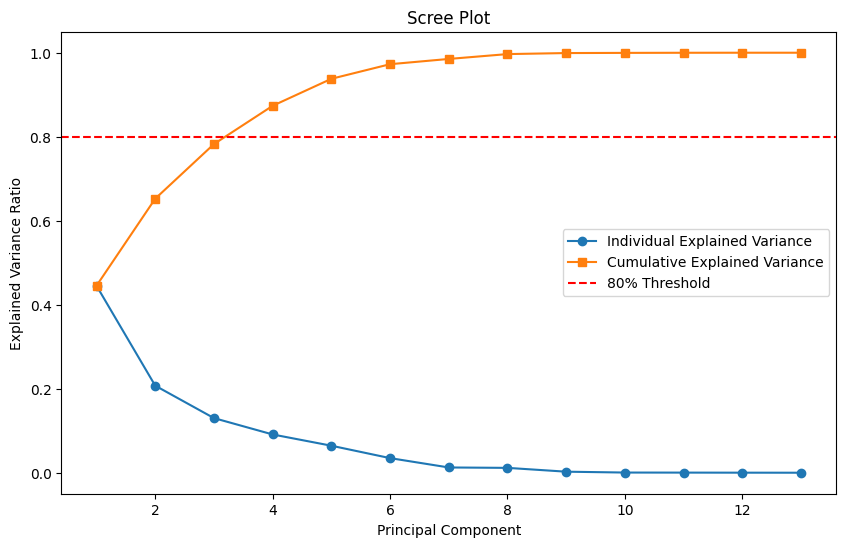

In [64]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker='o',
    label='Individual Explained Variance'
)

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='s',
    label='Cumulative Explained Variance'
)

plt.axhline(
    y=0.8,
    color='red',
    linestyle='--',
    label='80% Threshold'
)

plt.xlabel("Principal Component")

plt.ylabel("Explained Variance Ratio")

plt.title("Scree Plot")

plt.legend()

plt.show()

### PC1 알아내기

In [65]:
loading_df = pd.DataFrame(
    pca_full.components_.T,
    columns=[f"PC{i+1}" for i in range(len(features))],
    index=features
)

loading_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
voltage,0.005746,0.481307,-0.153426,0.011218,0.007356,0.861317,-0.050088,-0.002131,0.003773,0.000337,-0.000415,-0.014045,-2.187576e-06
current,0.026009,0.558997,-0.240916,0.020554,0.003148,-0.346462,-0.037845,-0.047214,-0.004239,0.001768,0.022317,0.710040,2.093954e-05
battery_temp,0.003592,0.306385,0.626841,-0.006311,0.005412,-0.020317,0.658689,0.280283,0.006225,0.000512,0.000601,0.015354,1.083823e-06
power,0.026121,0.557644,-0.238194,0.021375,0.003762,-0.366600,-0.009401,-0.042440,-0.011983,-0.003418,-0.022331,-0.702997,-1.983837e-05
delta_v,0.392448,0.003011,-0.008042,-0.084913,0.117429,-0.017559,-0.275388,0.663761,-0.553127,-0.047230,-0.001966,0.000231,-9.804997e-04
delta_i,0.412335,-0.021290,0.009215,0.021032,-0.032079,0.016521,0.104396,-0.244393,-0.103902,0.440014,0.534200,-0.016830,5.167300e-01
delta_t_temp,-0.009833,-0.007064,0.019149,0.721777,-0.673032,0.001308,-0.054079,0.123363,-0.084815,-0.014619,0.000103,-0.000006,5.714345e-04
delta_p,0.411960,-0.021813,0.009559,0.021884,-0.034264,0.017264,0.109983,-0.256873,-0.125510,0.536939,-0.459576,0.014422,-4.839583e-01
dv_dt,0.405697,0.002341,-0.005541,0.011858,-0.015014,-0.017453,-0.166191,0.376685,0.811604,0.078542,-0.016908,-0.006007,9.347693e-04
di_dt,0.412524,-0.021234,0.009070,0.017163,-0.026942,0.016408,0.102749,-0.240859,-0.012968,-0.520277,0.471850,-0.011825,-5.155505e-01


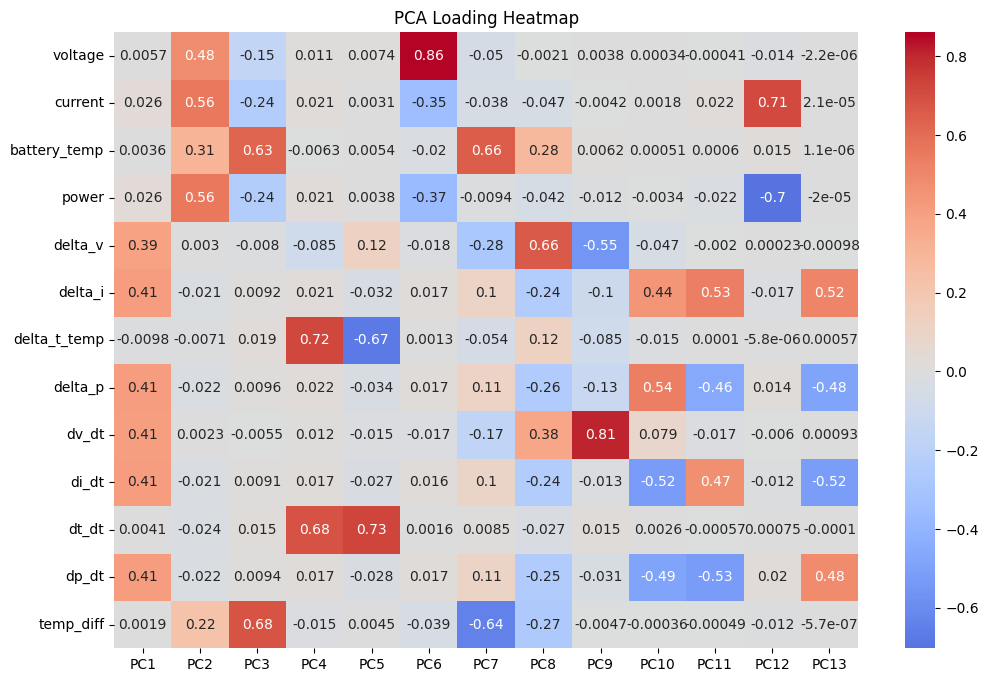

In [66]:
plt.figure(figsize=(12,8))

sns.heatmap(
    loading_df,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("PCA Loading Heatmap")

plt.show()

# K-means

In [57]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(X_pca)

pca_df["cluster"] = clusters

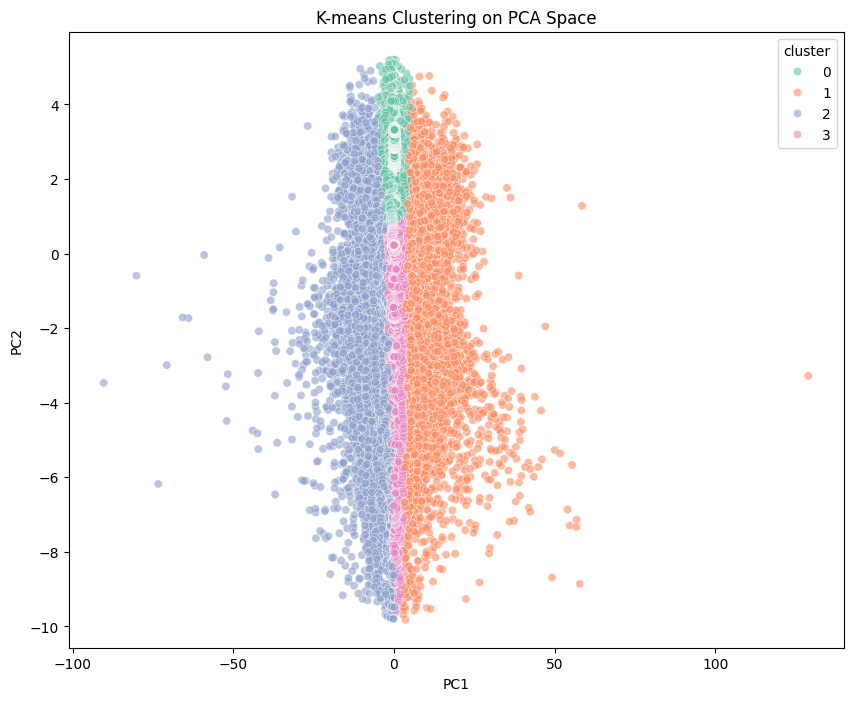

In [59]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set2",
    alpha=0.6
)

plt.title("K-means Clustering on PCA Space")

plt.show()

In [60]:
analysis_df["cluster"] = clusters

cluster_summary = analysis_df.groupby(
    "cluster"
)[pca_features].mean()

cluster_summary

,voltage,current,battery_temp,power,delta_v,delta_i,delta_t_temp,delta_p,dv_dt,di_dt,dt_dt,dp_dt,temp_diff
cluster,,,,,,,,,,,,,
0,383.490431,33.240168,15.881076,12860.338673,-0.009831,-0.157607,-0.000156,-59.951175,-0.098831,-1.574730,-0.000943,-599.004142,8.448128
1,365.370133,-43.600882,9.555479,-15370.482524,0.935394,7.495162,-0.003169,2679.690281,9.228530,74.937682,0.006847,26792.853503,3.763721
2,362.525527,-67.289169,9.086636,-23843.422480,-0.532734,-4.140327,-0.000337,-1469.563779,-5.326435,-41.371113,0.004789,-14683.213488,3.380579
3,369.952167,-26.118860,9.377244,-9481.060629,0.017429,0.150860,0.000237,53.773953,0.173884,1.509235,0.002334,537.976697,3.712230


| Cluster       | 주요 특징                                                    | 해석 가능한 배터리 상태    | 핵심 Stress 유형                                 | 프로젝트 관점 Insight                        | 가능 대응 전략                        |
| ------------- | -------------------------------------------------------- | ---------------- | -------------------------------------------- | -------------------------------------- | ------------------------------- |
| **Cluster 0** | current(+) / power(+) / battery_temp 높음 / temp_diff 가장 큼 | 충전 중 + 온도 상승 상태  | **Thermal Stress (열 스트레스)**                  | 충전 상황에서 배터리 내부 열 축적 가능성 존재             | 냉각 시스템 강화, 충전 전류 제어, 열관리 최적화    |
| **Cluster 1** | delta_i, di_dt, delta_p, dp_dt 매우 큼 / 급격한 변화             | 급가속·급부하·순간 방전 상태 | **Transient Electrical Stress (급변 전기 스트레스)** | 배터리 이상징후가 급격한 전류·전력 변화 상황에서 집중 발생 가능   | 급가속 제한, 전류 스무딩, 순간 부하 제어        |
| **Cluster 2** | current 매우 낮음(-) / power 매우 낮음(-) / voltage 낮음           | 지속적인 고부하 방전 상태   | **Sustained Heavy Load Stress (지속 부하 스트레스)** | 장시간 heavy discharge가 전압 저하 및 열화와 관련 가능 | 부하 분산, SoC 기반 출력 제한, 장시간 고출력 보호 |
| **Cluster 3** | 변화율 작음 / delta 값 작음 / 안정적 분포                             | 일반적인 정상 주행 상태    | **Normal Stable Operation**                  | 정상 상태에서는 변화율과 부하 fluctuation이 낮게 유지됨   | 정상 baseline 상태로 활용 가능           |


# Feature 선택

In [67]:
# feature 원본값을 사용할 수도 있지만,
# BSI는 "이상도" 기반 점수이므로 anomaly_score 컬럼을 사용
anomaly_score_cols = [
    f"{col}_anomaly_score" for col in features
]

X = analysis_df[anomaly_score_cols]
y = analysis_df["pseudo_label"]

## Correlation 기반 중요도 계산

In [68]:
corr_importance = []

for col in anomaly_score_cols:
    corr = analysis_df[col].corr(y)
    
    corr_importance.append({
        "feature": col.replace("_anomaly_score", ""),
        "corr_with_label": abs(corr)
    })

corr_importance_df = pd.DataFrame(corr_importance)

corr_importance_df = corr_importance_df.sort_values(
    by="corr_with_label",
    ascending=False
)

corr_importance_df

,feature,corr_with_label
9,di_dt,0.598728
5,delta_i,0.598189
8,dv_dt,0.592835
11,dp_dt,0.591409
7,delta_p,0.590697
4,delta_v,0.563808
1,current,0.398317
3,power,0.373764
0,voltage,0.281237
10,dt_dt,0.177454


| Feature | Weight | 담당 역할 (해석 편의성) |
| :--- | :---: | :--- |
| **`delta_i`** | 0.310574 | 순간 전류 변화량 스트레스 (약 31.1%) |
| **`delta_v`** | 0.292750 | 순간 전압 변화량 스트레스 (약 29.3%) |
| **`current`** | 0.206819 | 현재 흐르는 전류 부하 스트레스 (약 20.7%) |
| **`voltage`** | 0.145975 | 현재 전압의 과충방전 스트레스 (약 14.6%) |
| **`delta_t_temp`** | 0.028488 | 순간 온도 상승 스트레스 (약 2.8%) |
| **`temp_diff`** | 0.015310 | 외기 보정 배터리 온도 스트레스 (약 1.5%) |

## Random Forest 기반 중요도 계산

In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[94138     4]
 [    5  4090]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     94142
           1       1.00      1.00      1.00      4095

    accuracy                           1.00     98237
   macro avg       1.00      1.00      1.00     98237
weighted avg       1.00      1.00      1.00     98237



## 중요도 시각화

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=rf_importance_df,
    x="rf_importance",
    y="feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

NameError: name 'rf_importance_df' is not defined

<Figure size 1000x600 with 0 Axes>

## Correlation 중요도와 RF 중요도 비교

In [ ]:
importance_compare_df = pd.merge(
    corr_importance_df,
    rf_importance_df,
    on="feature",
    how="inner"
)

importance_compare_df = importance_compare_df.sort_values(
    by="rf_importance",
    ascending=False
)

importance_compare_df

-----------------------------------------------------------------------------

### 배터리 


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# source, time 기준 정렬
analysis_df = analysis_df.sort_values(["source", "time"]).reset_index(drop=True)

# 전력 부하의 크기 생성
# power는 충전/방전 방향에 따라 양수/음수일 수 있으므로,
# 열적 부하 관점에서는 절댓값 사용
analysis_df["abs_power"] = analysis_df["power"].abs()

# 데이터 시간 간격 확인
dt = analysis_df["delta_t"].median()

print("데이터 시간 간격 dt:", dt)

데이터 시간 간격 dt: 0.0999999999999996


In [43]:
# 10분부터 180분, 즉 3시간까지
rolling_minutes_list = list(range(10, 181, 10))

rolling_power_cols_3h = []

for minute in rolling_minutes_list:
    window_seconds = minute * 60
    window_size = int(window_seconds / dt)

    col_name = f"rolling_abs_power_{minute}min"

    analysis_df[col_name] = (
        analysis_df
        .groupby("source")["abs_power"]
        .transform(
            lambda x: x.rolling(
                window=window_size,
                min_periods=1
            ).mean()
        )
    )

    rolling_power_cols_3h.append(col_name)

rolling_power_cols_3h

['rolling_abs_power_10min',
 'rolling_abs_power_20min',
 'rolling_abs_power_30min',
 'rolling_abs_power_40min',
 'rolling_abs_power_50min',
 'rolling_abs_power_60min',
 'rolling_abs_power_70min',
 'rolling_abs_power_80min',
 'rolling_abs_power_90min',
 'rolling_abs_power_100min',
 'rolling_abs_power_110min',
 'rolling_abs_power_120min',
 'rolling_abs_power_130min',
 'rolling_abs_power_140min',
 'rolling_abs_power_150min',
 'rolling_abs_power_160min',
 'rolling_abs_power_170min',
 'rolling_abs_power_180min']

In [44]:
thermal_cols = [
    "battery_temp",
    "temp_diff",
    "delta_t_temp"
]

corr_result_3h = analysis_df[
    rolling_power_cols_3h + thermal_cols
].corr().loc[
    rolling_power_cols_3h,
    thermal_cols
]

corr_result_3h

,battery_temp,temp_diff,delta_t_temp
rolling_abs_power_10min,0.161597,0.017875,0.004555
rolling_abs_power_20min,0.223030,0.054992,0.003427
rolling_abs_power_30min,0.249631,0.081819,0.003365
rolling_abs_power_40min,0.259689,0.099765,0.003616
rolling_abs_power_50min,0.267398,0.113476,0.004171
rolling_abs_power_60min,0.267209,0.117997,0.004699
rolling_abs_power_70min,0.267805,0.123385,0.005189
rolling_abs_power_80min,0.268088,0.126610,0.005471
rolling_abs_power_90min,0.268293,0.128247,0.005612
rolling_abs_power_100min,0.268311,0.128378,0.005624


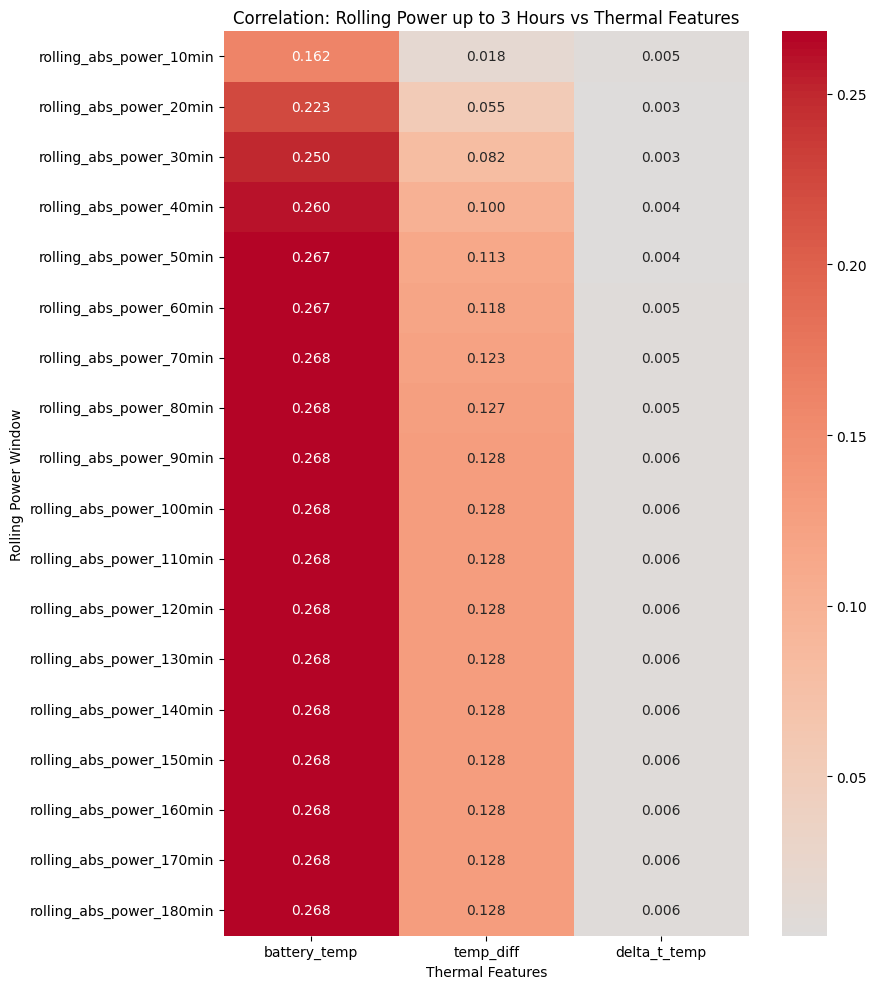

In [45]:
plt.figure(figsize=(9, 10))

sns.heatmap(
    corr_result_3h,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".3f"
)

plt.title("Correlation: Rolling Power up to 3 Hours vs Thermal Features")
plt.xlabel("Thermal Features")
plt.ylabel("Rolling Power Window")

plt.tight_layout()
plt.show()

In [46]:
battery_temp_corr_3h = corr_result_3h["battery_temp"].reset_index()
battery_temp_corr_3h.columns = ["rolling_power_feature", "corr_with_battery_temp"]

# 숫자형 minute 컬럼 추가
battery_temp_corr_3h["rolling_window_min"] = battery_temp_corr_3h[
    "rolling_power_feature"
].str.extract(r"(\d+)").astype(int)

battery_temp_corr_3h

,rolling_power_feature,corr_with_battery_temp,rolling_window_min
0,rolling_abs_power_10min,0.161597,10
1,rolling_abs_power_20min,0.223030,20
2,rolling_abs_power_30min,0.249631,30
3,rolling_abs_power_40min,0.259689,40
4,rolling_abs_power_50min,0.267398,50
5,rolling_abs_power_60min,0.267209,60
6,rolling_abs_power_70min,0.267805,70
7,rolling_abs_power_80min,0.268088,80
8,rolling_abs_power_90min,0.268293,90
9,rolling_abs_power_100min,0.268311,100


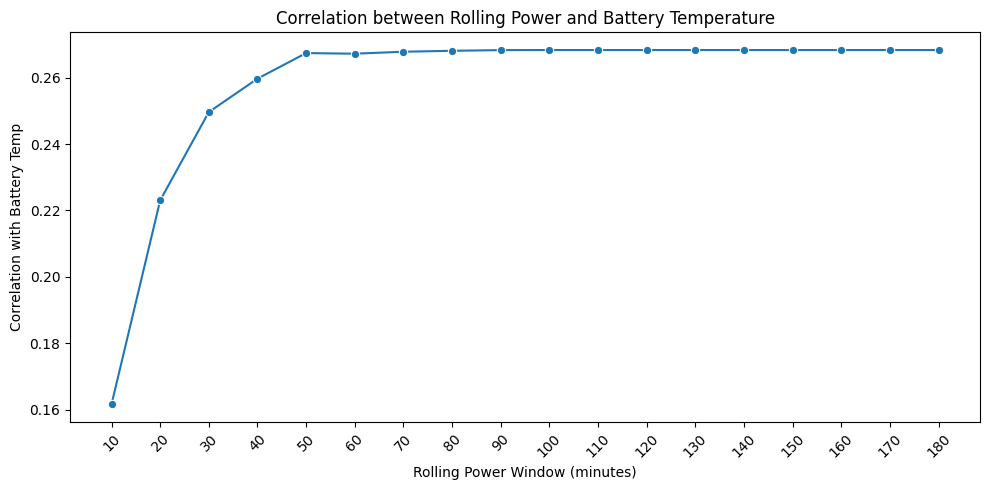

In [47]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=battery_temp_corr_3h,
    x="rolling_window_min",
    y="corr_with_battery_temp",
    marker="o"
)

plt.title("Correlation between Rolling Power and Battery Temperature")
plt.xlabel("Rolling Power Window (minutes)")
plt.ylabel("Correlation with Battery Temp")

plt.xticks(rolling_minutes_list, rotation=45)
plt.tight_layout()
plt.show()

In [48]:
temp_diff_corr_3h = corr_result_3h["temp_diff"].reset_index()
temp_diff_corr_3h.columns = ["rolling_power_feature", "corr_with_temp_diff"]

temp_diff_corr_3h["rolling_window_min"] = temp_diff_corr_3h[
    "rolling_power_feature"
].str.extract(r"(\d+)").astype(int)

temp_diff_corr_3h

,rolling_power_feature,corr_with_temp_diff,rolling_window_min
0,rolling_abs_power_10min,0.017875,10
1,rolling_abs_power_20min,0.054992,20
2,rolling_abs_power_30min,0.081819,30
3,rolling_abs_power_40min,0.099765,40
4,rolling_abs_power_50min,0.113476,50
5,rolling_abs_power_60min,0.117997,60
6,rolling_abs_power_70min,0.123385,70
7,rolling_abs_power_80min,0.126610,80
8,rolling_abs_power_90min,0.128247,90
9,rolling_abs_power_100min,0.128378,100


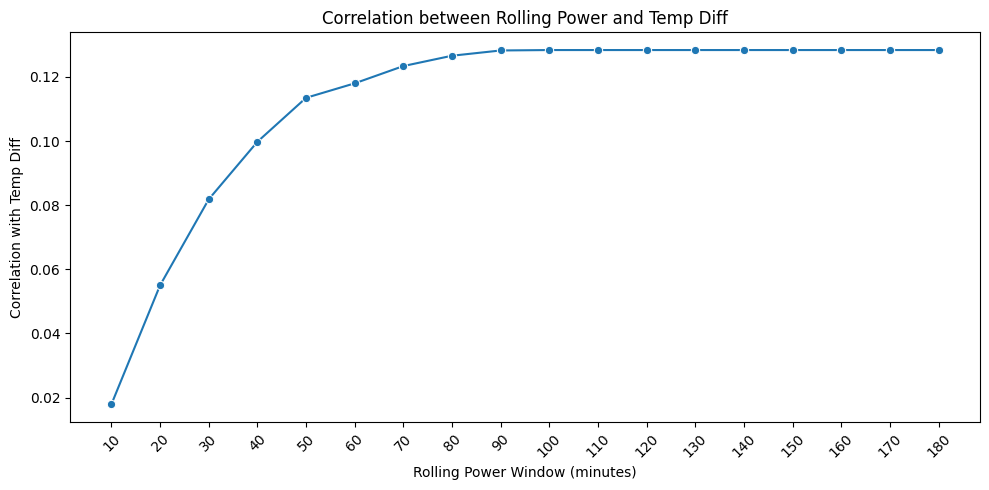

In [49]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=temp_diff_corr_3h,
    x="rolling_window_min",
    y="corr_with_temp_diff",
    marker="o"
)

plt.title("Correlation between Rolling Power and Temp Diff")
plt.xlabel("Rolling Power Window (minutes)")
plt.ylabel("Correlation with Temp Diff")

plt.xticks(rolling_minutes_list, rotation=45)
plt.tight_layout()
plt.show()

In [50]:
delta_temp_corr_3h = corr_result_3h["delta_t_temp"].reset_index()
delta_temp_corr_3h.columns = ["rolling_power_feature", "corr_with_delta_t_temp"]

delta_temp_corr_3h["rolling_window_min"] = delta_temp_corr_3h[
    "rolling_power_feature"
].str.extract(r"(\d+)").astype(int)

delta_temp_corr_3h

,rolling_power_feature,corr_with_delta_t_temp,rolling_window_min
0,rolling_abs_power_10min,0.004555,10
1,rolling_abs_power_20min,0.003427,20
2,rolling_abs_power_30min,0.003365,30
3,rolling_abs_power_40min,0.003616,40
4,rolling_abs_power_50min,0.004171,50
5,rolling_abs_power_60min,0.004699,60
6,rolling_abs_power_70min,0.005189,70
7,rolling_abs_power_80min,0.005471,80
8,rolling_abs_power_90min,0.005612,90
9,rolling_abs_power_100min,0.005624,100


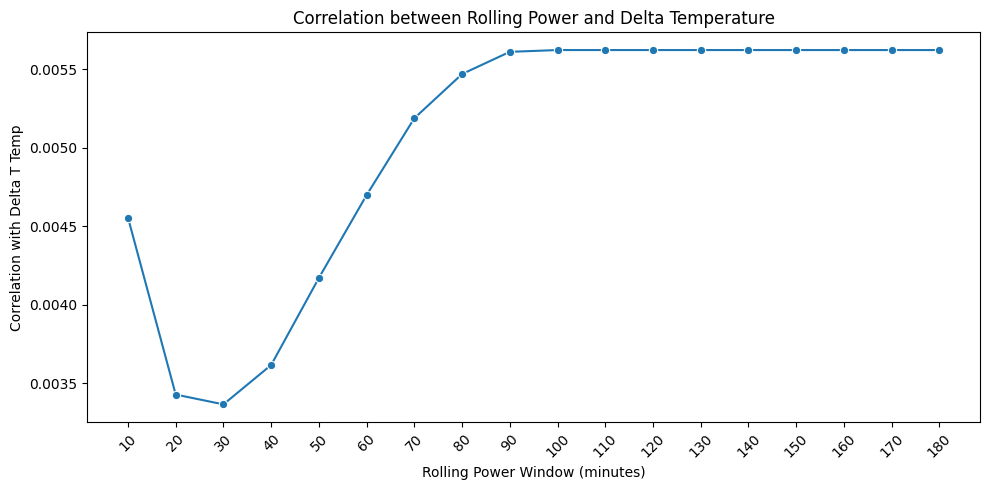

In [51]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=delta_temp_corr_3h,
    x="rolling_window_min",
    y="corr_with_delta_t_temp",
    marker="o"
)

plt.title("Correlation between Rolling Power and Delta Temperature")
plt.xlabel("Rolling Power Window (minutes)")
plt.ylabel("Correlation with Delta T Temp")

plt.xticks(rolling_minutes_list, rotation=45)
plt.tight_layout()
plt.show()

In [52]:
lag_minutes_list = list(range(10, 181, 10))

for lag_minute in lag_minutes_list:
    lag_seconds = lag_minute * 60
    lag_steps = int(lag_seconds / dt)

    future_col = f"temp_diff_future_{lag_minute}min"

    analysis_df[future_col] = (
        analysis_df
        .groupby("source")["temp_diff"]
        .shift(-lag_steps)
    )

In [53]:
lag_mapping_results_3h = []

for rolling_minute in rolling_minutes_list:
    power_col = f"rolling_abs_power_{rolling_minute}min"

    for lag_minute in lag_minutes_list:
        future_col = f"temp_diff_future_{lag_minute}min"

        temp_df = analysis_df[[power_col, future_col]].dropna()

        if len(temp_df) > 2:
            corr_value = temp_df[power_col].corr(temp_df[future_col])
        else:
            corr_value = np.nan

        lag_mapping_results_3h.append({
            "rolling_power_window_min": rolling_minute,
            "future_lag_min": lag_minute,
            "corr": corr_value,
            "valid_sample_count": len(temp_df)
        })

lag_mapping_df_3h = pd.DataFrame(lag_mapping_results_3h)

lag_mapping_df_3h

c:\Users\EL095\Microsoft\20260515\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\EL095\Microsoft\20260515\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,rolling_power_window_min,future_lag_min,corr,valid_sample_count
0,10,10,0.074353,330465
1,10,20,0.121717,192168
2,10,30,0.135750,117132
3,10,40,0.194777,73780
4,10,50,-0.226788,39092
...,...,...,...,...
319,180,140,NaN,0
320,180,150,NaN,0
321,180,160,NaN,0
322,180,170,NaN,0


In [54]:
lag_mapping_pivot_3h = lag_mapping_df_3h.pivot(
    index="rolling_power_window_min",
    columns="future_lag_min",
    values="corr"
)

lag_mapping_pivot_3h

future_lag_min,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180
rolling_power_window_min,,,,,,,,,,,,,,,,,,
10,0.074353,0.121717,0.135750,0.194777,-0.226788,-0.492836,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,0.126528,0.187943,0.260952,0.221422,-0.224863,-0.563092,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,0.160354,0.248566,0.282912,0.279212,-0.212025,-0.566413,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
40,0.190422,0.269626,0.323101,0.305913,-0.200994,-0.568613,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,0.201421,0.294799,0.343173,0.323853,-0.200184,-0.568613,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,0.213737,0.308934,0.356781,0.325294,-0.200184,-0.568613,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70,0.221136,0.317794,0.358287,0.325294,-0.200184,-0.568613,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80,0.225149,0.318599,0.358287,0.325294,-0.200184,-0.568613,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
90,0.225485,0.318599,0.358287,0.325294,-0.200184,-0.568613,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


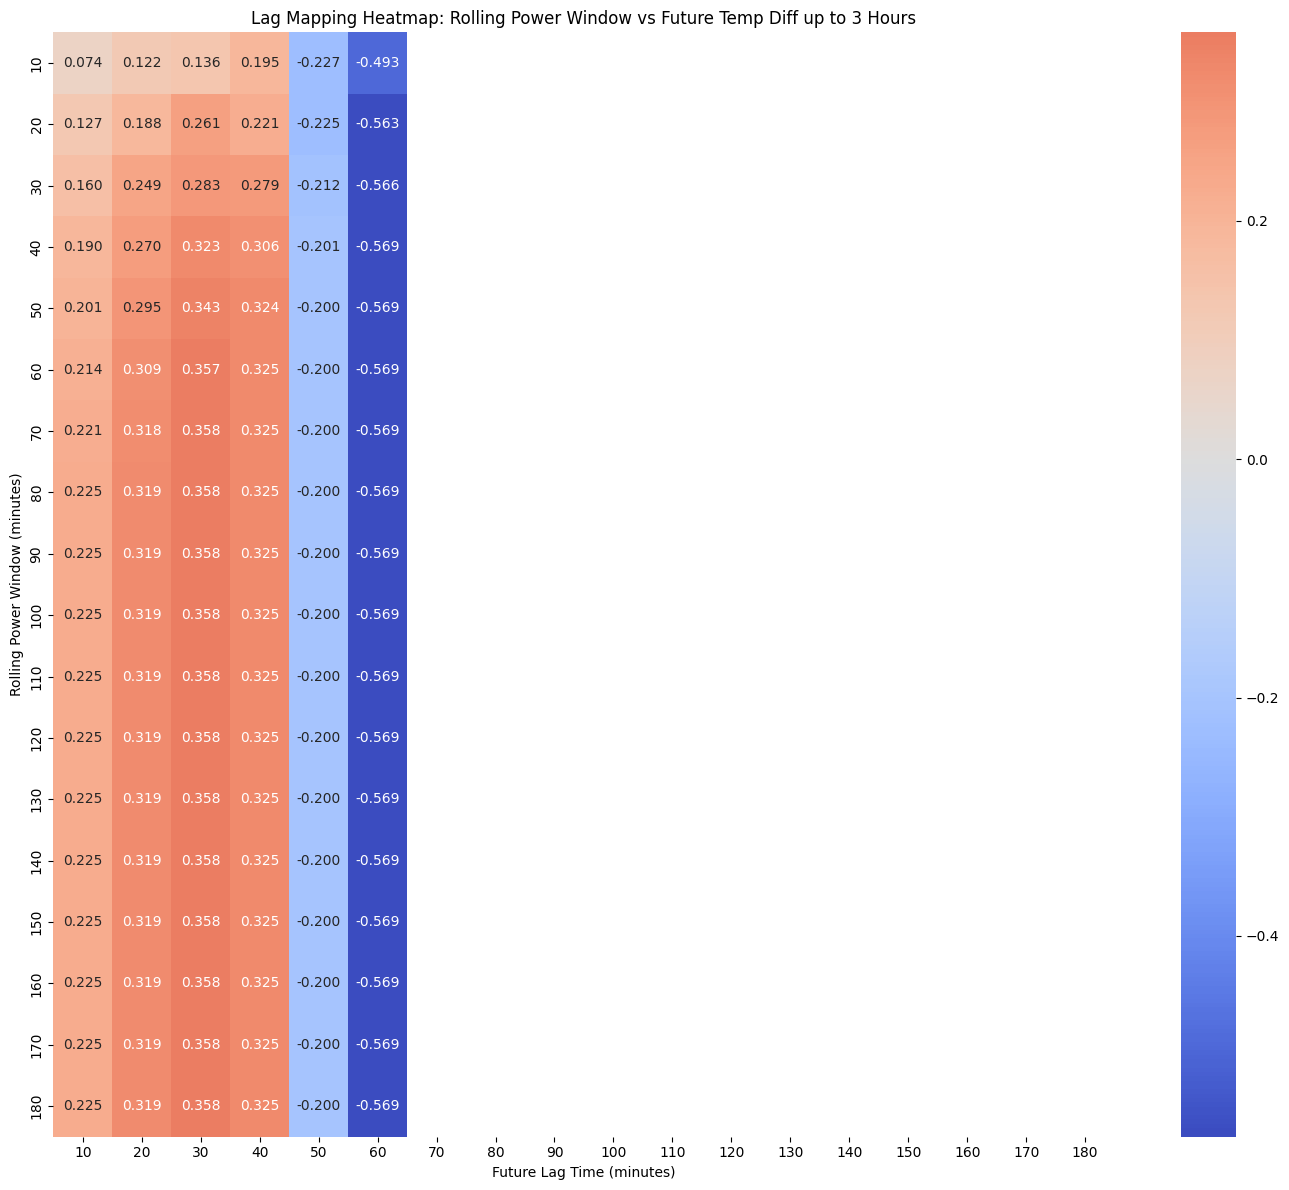

In [55]:
plt.figure(figsize=(14, 12))

sns.heatmap(
    lag_mapping_pivot_3h,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".3f"
)

plt.title("Lag Mapping Heatmap: Rolling Power Window vs Future Temp Diff up to 3 Hours")
plt.xlabel("Future Lag Time (minutes)")
plt.ylabel("Rolling Power Window (minutes)")

plt.tight_layout()
plt.show()

In [40]:
print("가장 높은 상관관계 조합")
print("Rolling Power Window:", best_result["rolling_power_window_min"], "분")
print("Future Lag Time:", best_result["future_lag_min"], "분 후")
print("Correlation:", best_result["corr"])

가장 높은 상관관계 조합


NameError: name 'best_result' is not defined

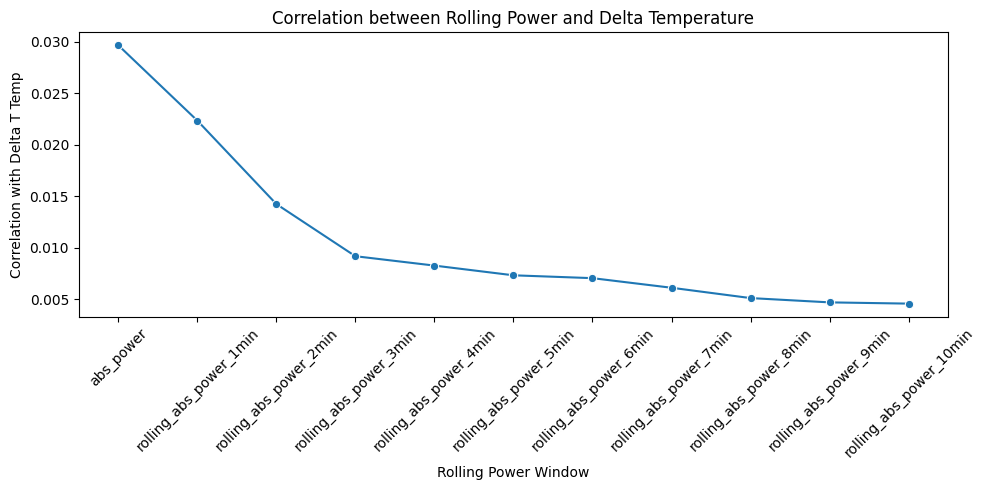

In [27]:
delta_temp_corr = corr_result["delta_t_temp"].reset_index()
delta_temp_corr.columns = ["feature", "corr_with_delta_t_temp"]

delta_temp_corr

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=delta_temp_corr,
    x="feature",
    y="corr_with_delta_t_temp",
    marker="o"
)

plt.title("Correlation between Rolling Power and Delta Temperature")
plt.xlabel("Rolling Power Window")
plt.ylabel("Correlation with Delta T Temp")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
# 기준 rolling power feature 선택
base_power_col = "rolling_abs_power_3min"

# 1분부터 10분 후까지 확인
max_lag_minutes = 10

lag_corr_results = []

for lag_minute in range(1, max_lag_minutes + 1):
    lag_seconds = lag_minute * 60
    lag_steps = int(lag_seconds / dt)

    future_col = f"temp_diff_future_{lag_minute}min"

    analysis_df[future_col] = (
        analysis_df
        .groupby("source")["temp_diff"]
        .shift(-lag_steps)
    )

    corr_value = analysis_df[
        [base_power_col, future_col]
    ].corr().iloc[0, 1]

    lag_corr_results.append({
        "lag_minutes": lag_minute,
        "corr_with_future_temp_diff": corr_value
    })

lag_corr_df = pd.DataFrame(lag_corr_results)

lag_corr_df

,lag_minutes,corr_with_future_temp_diff
0,1,0.000409
1,2,0.008740
2,3,0.015022
3,4,0.017983
4,5,0.018497
5,6,0.016069
6,7,0.009741
7,8,0.008101
8,9,0.007442
9,10,0.010155


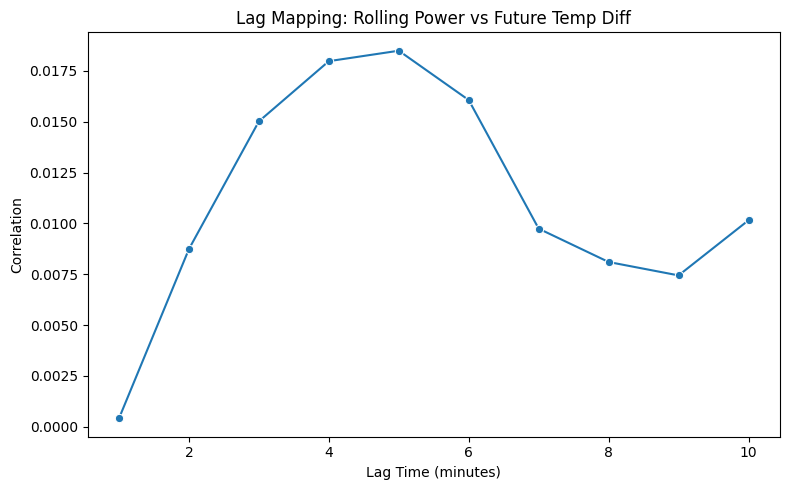

In [29]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=lag_corr_df,
    x="lag_minutes",
    y="corr_with_future_temp_diff",
    marker="o"
)

plt.title("Lag Mapping: Rolling Power vs Future Temp Diff")
plt.xlabel("Lag Time (minutes)")
plt.ylabel("Correlation")

plt.tight_layout()
plt.show()

In [30]:
lag_mapping_results = []

for power_minute in range(1, max_minutes + 1):
    power_col = f"rolling_abs_power_{power_minute}min"

    for lag_minute in range(1, max_lag_minutes + 1):
        lag_seconds = lag_minute * 60
        lag_steps = int(lag_seconds / dt)

        future_col = f"temp_diff_future_{lag_minute}min"

        if future_col not in analysis_df.columns:
            analysis_df[future_col] = (
                analysis_df
                .groupby("source")["temp_diff"]
                .shift(-lag_steps)
            )

        corr_value = analysis_df[
            [power_col, future_col]
        ].corr().iloc[0, 1]

        lag_mapping_results.append({
            "rolling_power_window_min": power_minute,
            "future_lag_min": lag_minute,
            "corr": corr_value
        })

lag_mapping_df = pd.DataFrame(lag_mapping_results)

lag_mapping_df.head()

,rolling_power_window_min,future_lag_min,corr
0,1,1,-0.011421
1,1,2,-0.002256
2,1,3,0.008569
3,1,4,0.010261
4,1,5,0.013860


In [31]:
lag_mapping_pivot = lag_mapping_df.pivot(
    index="rolling_power_window_min",
    columns="future_lag_min",
    values="corr"
)

lag_mapping_pivot

future_lag_min,1,2,3,4,5,6,7,8,9,10
rolling_power_window_min,,,,,,,,,,
1,-0.011421,-0.002256,0.008569,0.010261,0.013860,0.014424,0.004704,0.001019,-0.001681,-0.000234
2,-0.005865,0.004864,0.011726,0.014756,0.017738,0.014820,0.007294,0.004173,0.003305,0.004150
3,0.000409,0.008740,0.015022,0.017983,0.018497,0.016069,0.009741,0.008101,0.007442,0.010155
4,0.004795,0.012445,0.017976,0.019233,0.019852,0.018070,0.013365,0.012189,0.013150,0.018859
5,0.009074,0.015883,0.019629,0.020964,0.021992,0.021461,0.017557,0.017882,0.021421,0.029333
6,0.013101,0.018219,0.021692,0.023349,0.025371,0.025602,0.023247,0.025871,0.031454,0.039880
7,0.015944,0.020638,0.024133,0.026623,0.029328,0.030990,0.030820,0.035324,0.041535,0.049993
8,0.018597,0.023159,0.027198,0.030303,0.034289,0.037984,0.039623,0.044799,0.051175,0.058744
9,0.021149,0.026070,0.030520,0.034766,0.040601,0.046035,0.048409,0.053834,0.059532,0.066616


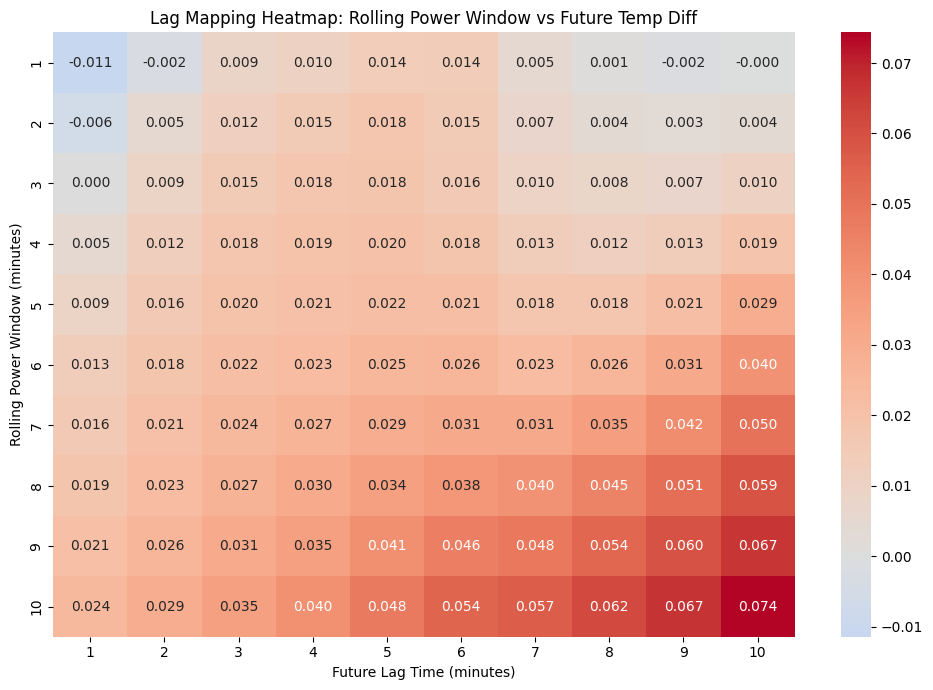

In [32]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    lag_mapping_pivot,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".3f"
)

plt.title("Lag Mapping Heatmap: Rolling Power Window vs Future Temp Diff")
plt.xlabel("Future Lag Time (minutes)")
plt.ylabel("Rolling Power Window (minutes)")

plt.tight_layout()
plt.show()